<a href="https://colab.research.google.com/github/sofiaputri22-design/skripsi-ml-app/blob/main/Copy_of_Klasifikasi_Estimasi_Risiko_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. IMPORT LIBRARY**

In [ ]:
# --- LANGKAH 1: IMPORT LIBRARY ---
import pandas as pd # Untuk manipulasi dan analisis data dalam bentuk tabel
import numpy as np # Untuk operasi matematika dan array tingkat lanjut
import matplotlib.pyplot as plt # Untuk pembuatan grafik dan visualisasi data
import seaborn as sns # Untuk visualisasi data statistik yang lebih informatif
import ipywidgets as widgets # Untuk membuat elemen antarmuka interaktif (slider, dropdown)
from IPython.display import display, clear_output, HTML # Untuk menampilkan output UI/HTML khusus di notebook

# Preprocessing & Feature Selection
from sklearn.model_selection import train_test_split, cross_val_score # Untuk membagi data dan validasi silang model
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix # Untuk mengevaluasi performa prediksi model secara mendalam
from sklearn.feature_selection import SelectKBest, chi2 # Untuk memilih fitur paling berpengaruh menggunakan uji statistik
from sklearn.preprocessing import OneHotEncoder # Untuk mengubah data kategori menjadi format numerik

# Model Machine Learning
from imblearn.ensemble import BalancedRandomForestClassifier # Algoritma utama untuk menangani data yang tidak seimbang (imbalanced data)

# **2. LOAD & CLEAN DATA**

In [ ]:
df = pd.read_csv('Dataset Klasifikasi - Copy.csv', sep=';', encoding='latin1')

# Menampilkan 5 data teratas dan ringkasan dataset
print("Info Dataset:")
display(df.info())
print("\nJumlah Nilai Kosong:")
display(df.isnull().sum())
display(df.head())

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 957 entries, 0 to 956
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Direction            957 non-null    object
 1   Tipe Cahaya          957 non-null    object
 2   Cuaca                957 non-null    object
 3   Fungsi Jalan         957 non-null    object
 4   Kelas Jalan          957 non-null    object
 5   Geometri Jalan       957 non-null    object
 6   Tipe Jalan           957 non-null    object
 7   Kecepatan            957 non-null    int64 
 8   Jenis Jalan          957 non-null    object
 9   Kecamatan            957 non-null    object
 10  Jenis Luka           957 non-null    object
 11  Age                  814 non-null    object
 12  jenis kelamin        957 non-null    object
 13  jenis kendaraan      957 non-null    object
 14  Atribut_Keselamatan  957 non-null    object
 15  Kepemilikan_SIM      957 non-null    object

None


Jumlah Nilai Kosong:


,0
Direction,0
Tipe Cahaya,0
Cuaca,0
Fungsi Jalan,0
Kelas Jalan,0
Geometri Jalan,0
Tipe Jalan,0
Kecepatan,0
Jenis Jalan,0
Kecamatan,0


,Direction,Tipe Cahaya,Cuaca,Fungsi Jalan,Kelas Jalan,Geometri Jalan,Tipe Jalan,Kecepatan,Jenis Jalan,Kecamatan,Jenis Luka,Age,jenis kelamin,jenis kendaraan,Atribut_Keselamatan,Kepemilikan_SIM
0,Utara (0°),Terang / Jelas,Cerah,Lokal / Lingkungan,II (Jalan Sedang utk beban s/d 10 ton & 12m P...,Lurus,2/2 TB (2 Lajur/2 Arah Tanpa Batas Median),50,Jalan Kota / Kabupaten,Balongpanggang,Kecelakaan Ringan,46-65,Perempuan,Sepeda Angin,Tidak (Sepeda Angin),Tidak Ada
1,Utara (0°),Terang / Jelas,Cerah,Lokal / Lingkungan,II (Jalan Sedang utk beban s/d 10 ton & 12m P...,Lurus,2/2 TB (2 Lajur/2 Arah Tanpa Batas Median),50,Jalan Kota / Kabupaten,Balongpanggang,Kecelakaan Ringan,46-65,Perempuan,Sepeda Angin,Tidak (Sepeda Angin),Tidak Ada
2,Utara (0°),Terang / Jelas,Cerah,Lokal / Lingkungan,II (Jalan Sedang utk beban s/d 10 ton & 12m P...,Lurus,2/2 TB (2 Lajur/2 Arah Tanpa Batas Median),50,Jalan Kota / Kabupaten,Balongpanggang,Kecelakaan Ringan,46-65,Perempuan,Sepeda Angin,Tidak (Sepeda Angin),Tidak Ada
3,Timur (90°),Terang / Jelas,Cerah,Lokal / Lingkungan,II (Jalan Sedang utk beban s/d 10 ton & 12m P...,Lurus,2/2 TB (2 Lajur/2 Arah Tanpa Batas Median),40,Jalan Kota / Kabupaten,Sidayu,Kecelakaan Ringan,46-65,Laki-laki,R2 (Sepeda Motor),Tidak,Tidak
4,Timur (90°),Terang / Jelas,Cerah,Lokal / Lingkungan,II (Jalan Sedang utk beban s/d 10 ton & 12m P...,Lurus,2/2 TB (2 Lajur/2 Arah Tanpa Batas Median),40,Jalan Kota / Kabupaten,Kebomas,Kecelakaan Ringan,<17,Perempuan,R2 (Sepeda Motor),Iya,Iya


# **3. DATA CLEANING & PREPROCESSING**

In [ ]:
# --- LANGKAH 3: DATA CLEANING & PREPROCESSING ---

# 1. Merapikan nama kolom: hapus spasi tambahan dan jadikan lowercase
df.columns = df.columns.str.strip().str.lower()

# 2. Merapikan teks di semua kolom bertipe 'object' (kategori)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

# 3. Menangani Missing Values pada kolom 'age'
# Mengganti string 'nan' (hasil dari konversi astype) atau '(blanks)' menjadi 'tidak diketahui'
df['age'] = df['age'].replace(['nan', '(blanks)', 'none'], 'tidak diketahui')

# 4. Memastikan kolom 'kecepatan' adalah numerik
df['kecepatan'] = pd.to_numeric(df['kecepatan'], errors='coerce')
df['kecepatan'] = df['kecepatan'].fillna(df['kecepatan'].median())

print("Data cleaning selesai. Contoh data terbaru:")
display(df.head())

Data cleaning selesai. Contoh data terbaru:


,direction,tipe cahaya,cuaca,fungsi jalan,kelas jalan,geometri jalan,tipe jalan,kecepatan,jenis jalan,kecamatan,jenis luka,age,jenis kelamin,jenis kendaraan,atribut_keselamatan,kepemilikan_sim
0,utara (0°),terang / jelas,cerah,lokal / lingkungan,ii (jalan sedang utk beban s/d 10 ton & 12m p...,lurus,2/2 tb (2 lajur/2 arah tanpa batas median),50,jalan kota / kabupaten,balongpanggang,kecelakaan ringan,46-65,perempuan,sepeda angin,tidak (sepeda angin),tidak ada
1,utara (0°),terang / jelas,cerah,lokal / lingkungan,ii (jalan sedang utk beban s/d 10 ton & 12m p...,lurus,2/2 tb (2 lajur/2 arah tanpa batas median),50,jalan kota / kabupaten,balongpanggang,kecelakaan ringan,46-65,perempuan,sepeda angin,tidak (sepeda angin),tidak ada
2,utara (0°),terang / jelas,cerah,lokal / lingkungan,ii (jalan sedang utk beban s/d 10 ton & 12m p...,lurus,2/2 tb (2 lajur/2 arah tanpa batas median),50,jalan kota / kabupaten,balongpanggang,kecelakaan ringan,46-65,perempuan,sepeda angin,tidak (sepeda angin),tidak ada
3,timur (90°),terang / jelas,cerah,lokal / lingkungan,ii (jalan sedang utk beban s/d 10 ton & 12m p...,lurus,2/2 tb (2 lajur/2 arah tanpa batas median),40,jalan kota / kabupaten,sidayu,kecelakaan ringan,46-65,laki-laki,r2 (sepeda motor),tidak,tidak
4,timur (90°),terang / jelas,cerah,lokal / lingkungan,ii (jalan sedang utk beban s/d 10 ton & 12m p...,lurus,2/2 tb (2 lajur/2 arah tanpa batas median),40,jalan kota / kabupaten,kebomas,kecelakaan ringan,<17,perempuan,r2 (sepeda motor),iya,iya


# **4. EXPLORATORY DATA ANALYSIS (EDA)**

**DISTRIBUSI JUMLAH JENIS LUKA**

In [ ]:
df['jenis luka'].value_counts()

,count
jenis luka,
kecelakaan ringan,824
kecelakaan berat,102
kecelakaan fatal,31


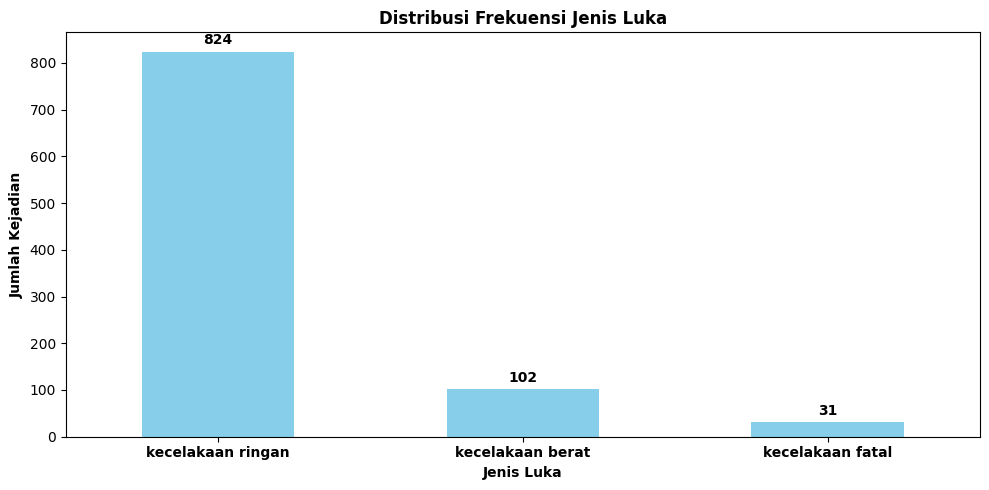

In [ ]:
# 1. Visualisasi Distribusi Jenis Luka (Frekuensi Tunggal)
plt.figure(figsize=(10, 5))
ax = df['jenis luka'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribusi Frekuensi Jenis Luka', fontweight='bold')
plt.xlabel('Jenis Luka', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
for container in ax.containers:
    ax.bar_label(container, padding=3, fontweight='bold')
plt.tight_layout()
plt.show()

**DISTRIBUSI JENIS KENDARAAN**

In [ ]:
df['jenis kendaraan'].value_counts()

,count
jenis kendaraan,
r2 (sepeda motor),713
mini bus,57
mini truk,52
truk berat / tronton,28
pick up,26
medium truk,17
trailer 20 feet,12
sepeda angin,10
truck,9


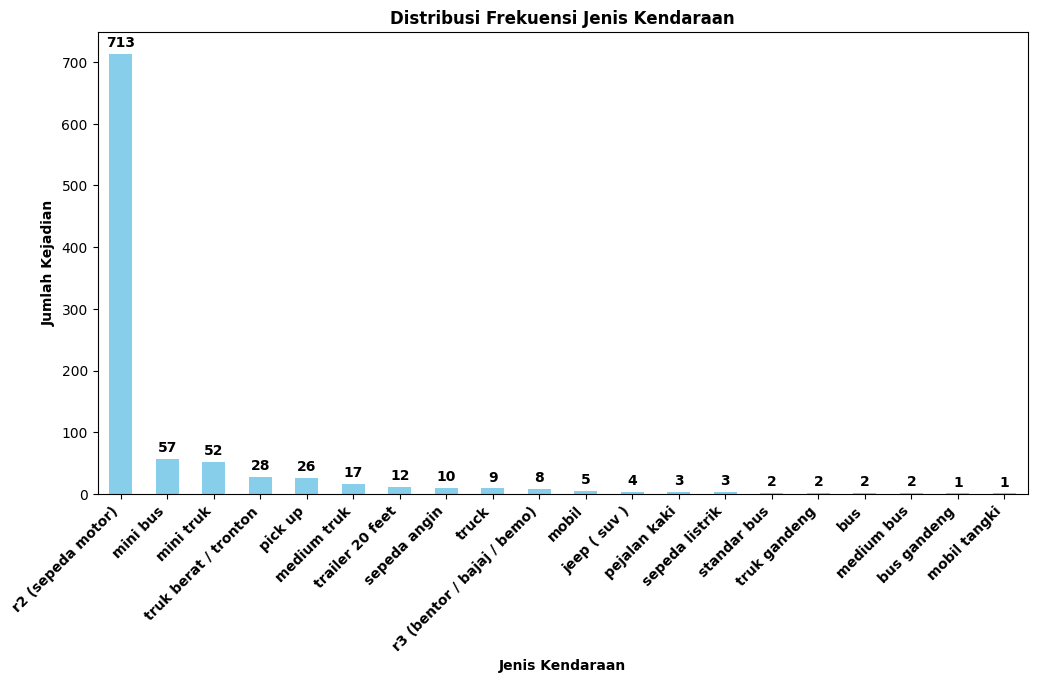

------------------------------


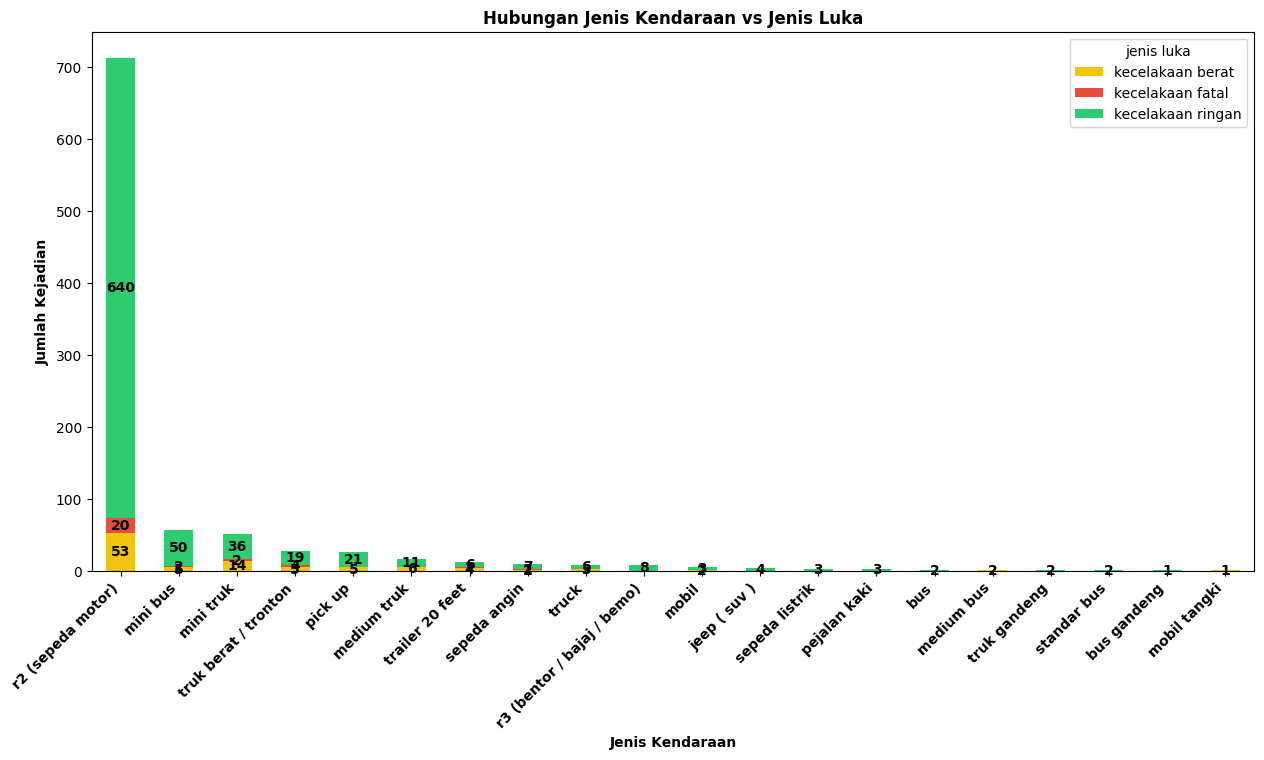

In [ ]:
# 1. Visualisasi Distribusi Jenis Kendaraan (Frekuensi Tunggal)
plt.figure(figsize=(12, 6))
ax1 = df['jenis kendaraan'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribusi Frekuensi Jenis Kendaraan', fontweight='bold')
plt.xlabel('Jenis Kendaraan', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold')
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontweight='bold')
plt.show()

print("-"*30)

# 2. EDA: Jenis Kendaraan vs Jenis Luka (Stacked Bar)
ct_kendaraan = pd.crosstab(df['jenis kendaraan'], df['jenis luka'])
ct_kendaraan = ct_kendaraan.loc[ct_kendaraan.sum(axis=1).sort_values(ascending=False).index]
colors = ['#f1c40f', '#e74c3c', '#2ecc71']
ax2 = ct_kendaraan.plot(kind='bar', stacked=True, figsize=(15, 7), color=colors)
plt.title('Hubungan Jenis Kendaraan vs Jenis Luka', fontweight='bold')
plt.xlabel('Jenis Kendaraan', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold')
for container in ax2.containers:
    ax2.bar_label(container, label_type='center', color='black', fontweight='bold', labels=[f'{int(v)}' if v > 0 else '' for v in container.datavalues])
plt.show()

**DISTRIBUSI CUACA**

In [ ]:
df['cuaca'].value_counts()

,count
cuaca,
cerah,951
hujan/ grimis,6


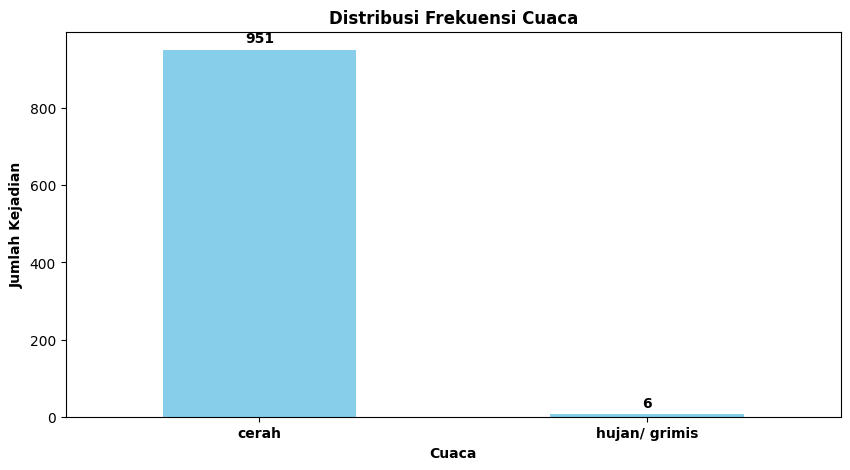

------------------------------


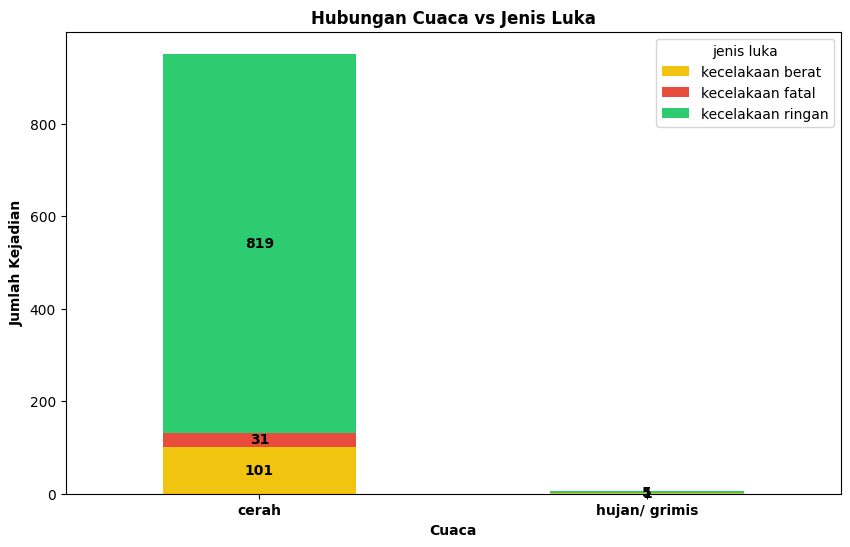

In [ ]:
# 1. Visualisasi Distribusi Cuaca (Frekuensi Tunggal)
plt.figure(figsize=(10, 5))
ax1 = df['cuaca'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribusi Frekuensi Cuaca', fontweight='bold')
plt.xlabel('Cuaca', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontweight='bold')
plt.show()

print("-"*30)

# 2. EDA: Cuaca vs Jenis Luka (Stacked Bar)
ct_cuaca = pd.crosstab(df['cuaca'], df['jenis luka'])
colors = ['#f1c40f', '#e74c3c', '#2ecc71']
ax2 = ct_cuaca.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Hubungan Cuaca vs Jenis Luka', fontweight='bold')
plt.xlabel('Cuaca', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
for container in ax2.containers:
    ax2.bar_label(container, label_type='center', color='black', fontweight='bold', labels=[f'{int(v)}' if v > 0 else '' for v in container.datavalues])
plt.show()

**DISTRIBUSI TIPE CAHAYA**

In [ ]:
df['tipe cahaya'].value_counts()

,count
tipe cahaya,
terang / jelas,888
gelap / sulit terlihat,69


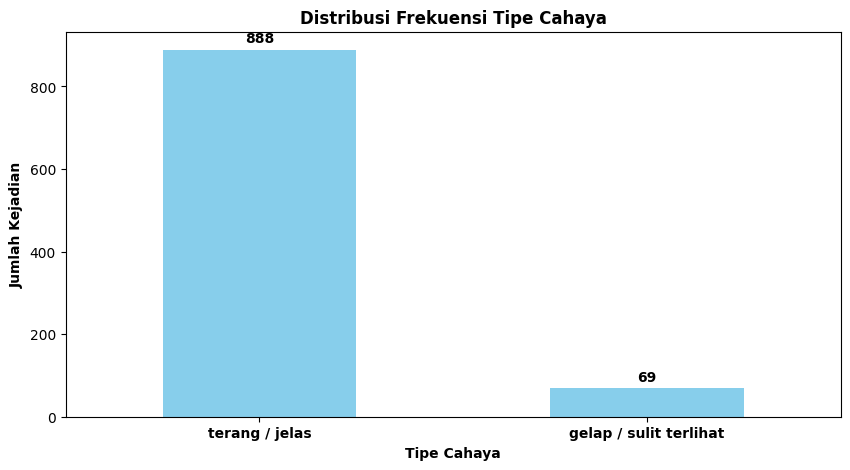

------------------------------


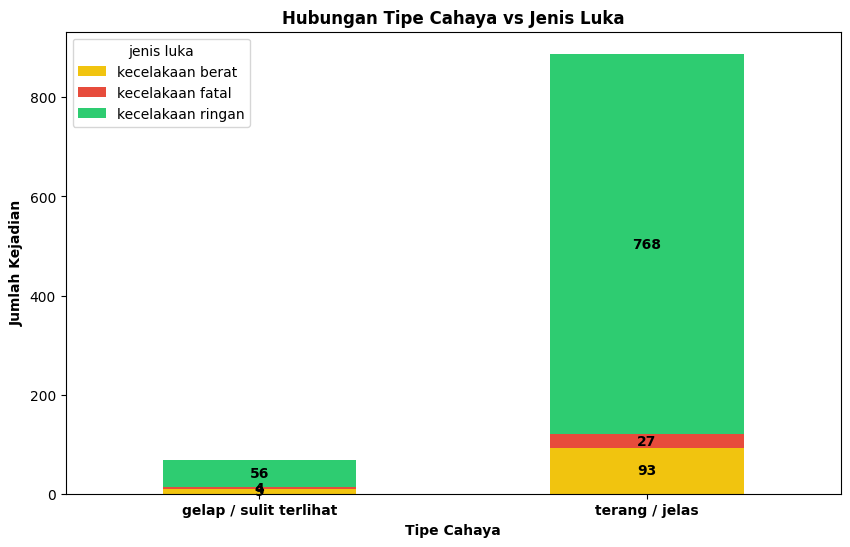

In [ ]:
# 1. Visualisasi Distribusi Tipe Cahaya (Frekuensi Tunggal)
plt.figure(figsize=(10, 5))
ax1 = df['tipe cahaya'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribusi Frekuensi Tipe Cahaya', fontweight='bold')
plt.xlabel('Tipe Cahaya', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontweight='bold')
plt.show()

print("-"*30)

# 2. EDA: Tipe Cahaya vs Jenis Luka
ct_cahaya = pd.crosstab(df['tipe cahaya'], df['jenis luka'])
colors = ['#f1c40f', '#e74c3c', '#2ecc71']
ax2 = ct_cahaya.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Hubungan Tipe Cahaya vs Jenis Luka', fontweight='bold')
plt.xlabel('Tipe Cahaya', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
for container in ax2.containers:
    ax2.bar_label(container, label_type='center', color='black', fontweight='bold', labels=[f'{int(v)}' if v > 0 else '' for v in container.datavalues])
plt.show()

**DISTRIBUSI KECAMATAN**

In [ ]:
df['kecamatan'].value_counts()

,count
kecamatan,
driyorejo,116
menganti,103
cerme,98
kebomas,93
manyar,83
duduk sampeyan,82
wringinanom,65
bungah,48
kedamean,47


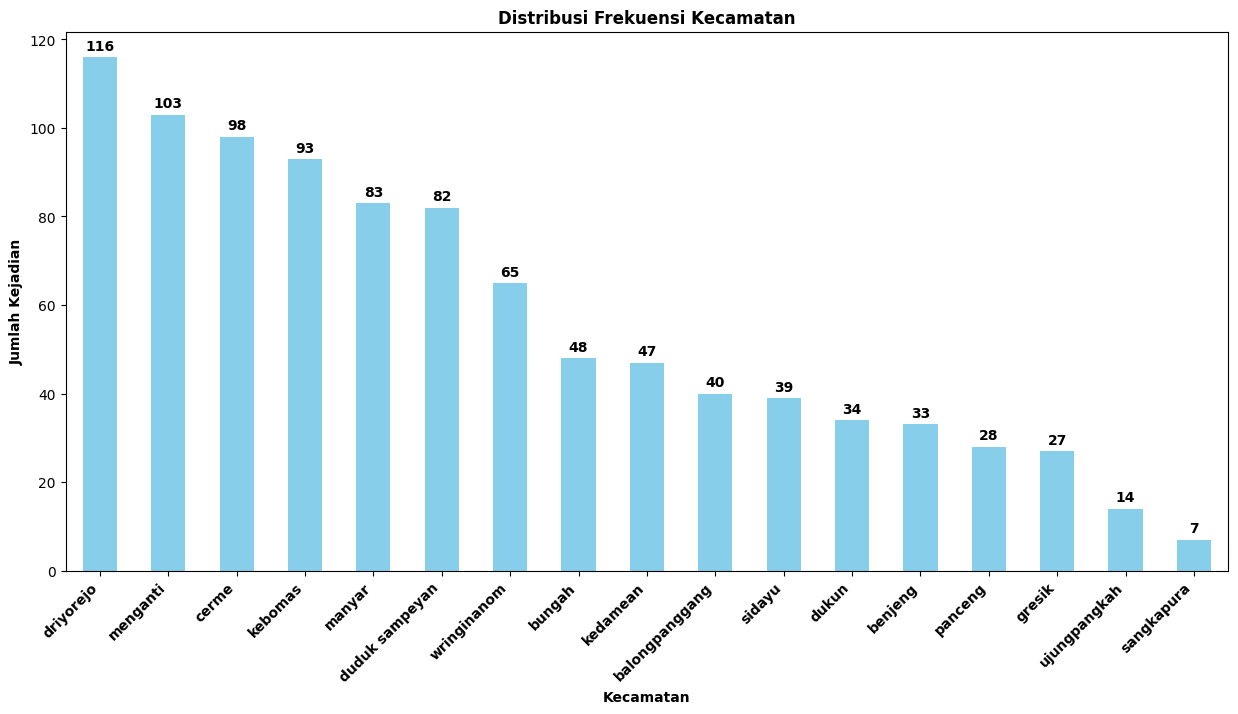

------------------------------


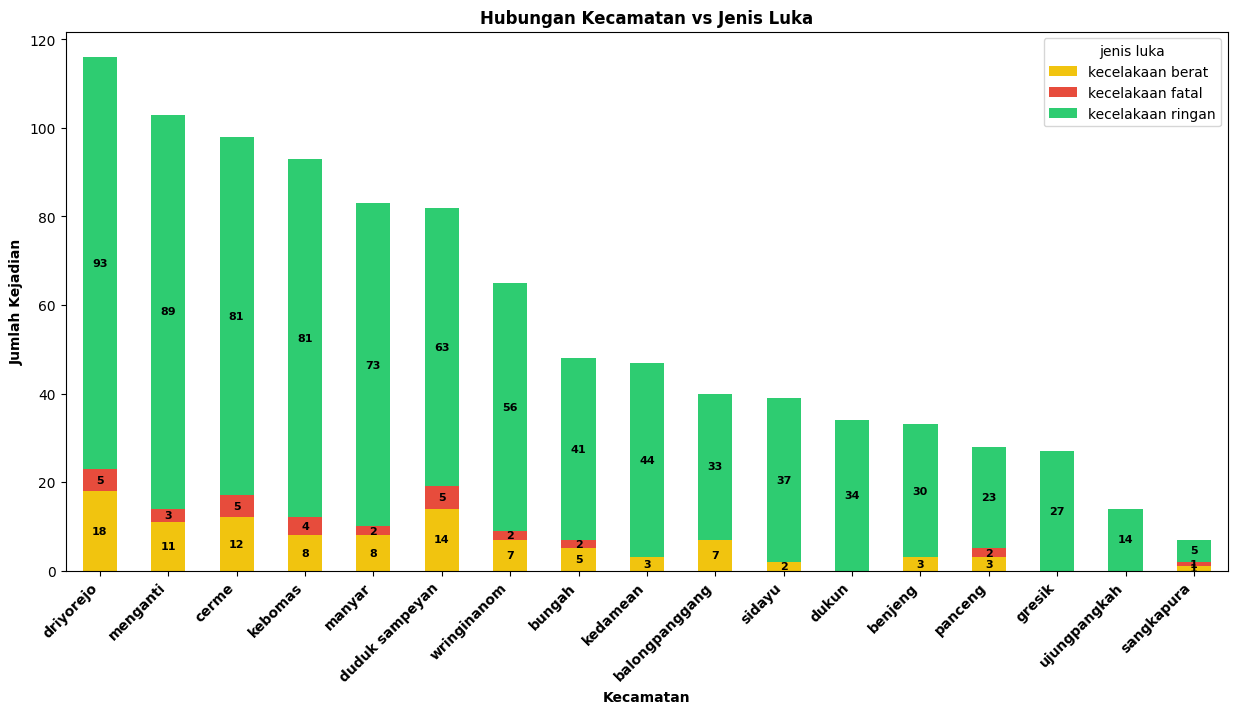

In [ ]:
# 1. Visualisasi Distribusi Kecamatan (Frekuensi Tunggal)
plt.figure(figsize=(15, 7))
ax1 = df['kecamatan'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribusi Frekuensi Kecamatan', fontweight='bold')
plt.xlabel('Kecamatan', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold')
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontweight='bold')
plt.show()

print("-"*30)

# 2. EDA: Kecamatan vs Jenis Luka
ct_kec = pd.crosstab(df['kecamatan'], df['jenis luka'])
ct_kec = ct_kec.loc[ct_kec.sum(axis=1).sort_values(ascending=False).index]
colors = ['#f1c40f', '#e74c3c', '#2ecc71']
ax2 = ct_kec.plot(kind='bar', stacked=True, figsize=(15, 7), color=colors)
plt.title('Hubungan Kecamatan vs Jenis Luka', fontweight='bold')
plt.xlabel('Kecamatan', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold')
for container in ax2.containers:
    ax2.bar_label(container, label_type='center', color='black', size=8, fontweight='bold', labels=[f'{int(v)}' if v > 0 else '' for v in container.datavalues])
plt.show()

**DISTRIBUSI JENIS JALAN**

In [ ]:
df['fungsi jalan'].value_counts()

,count
fungsi jalan,
lokal / lingkungan,618
arteri,197
kolektor,125
tol,17


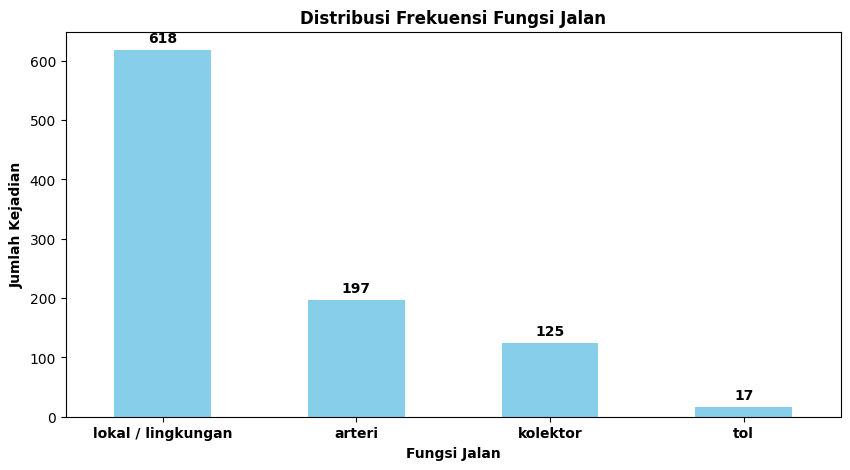

------------------------------


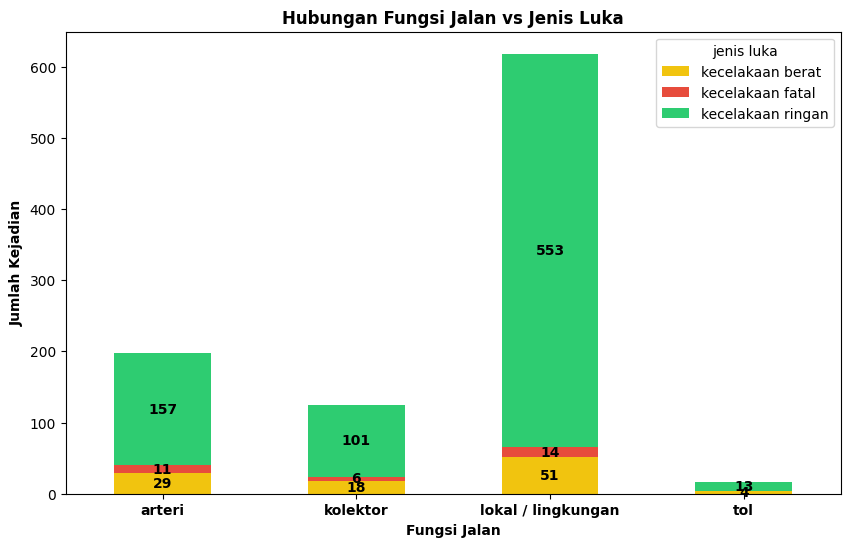

In [ ]:
# 1. Visualisasi Distribusi Fungsi Jalan (Frekuensi Tunggal)
plt.figure(figsize=(10, 5))
ax1 = df['fungsi jalan'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribusi Frekuensi Fungsi Jalan', fontweight='bold')
plt.xlabel('Fungsi Jalan', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontweight='bold')
plt.show()

print("-"*30)

# 2. EDA: Fungsi Jalan vs Jenis Luka
ct_fungsi = pd.crosstab(df['fungsi jalan'], df['jenis luka'])
colors = ['#f1c40f', '#e74c3c', '#2ecc71']
ax2 = ct_fungsi.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Hubungan Fungsi Jalan vs Jenis Luka', fontweight='bold')
plt.xlabel('Fungsi Jalan', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
for container in ax2.containers:
    ax2.bar_label(container, label_type='center', color='black', fontweight='bold', labels=[f'{int(v)}' if v > 0 else '' for v in container.datavalues])
plt.show()

**DISTRIBUSI DIRECTION**

In [ ]:
df['direction'].value_counts()

,count
direction,
timur (90°),290
barat (270°),284
utara (0°),201
selatan (180°),182


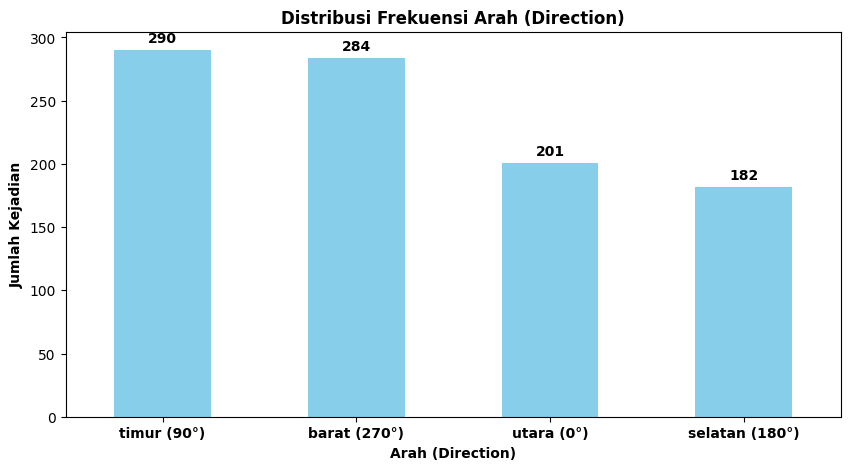

------------------------------


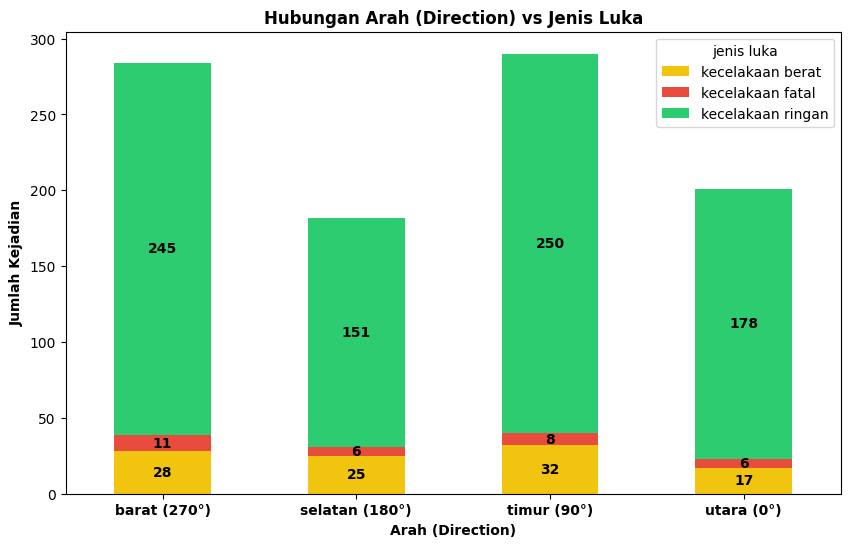

In [ ]:
# 1. Visualisasi Distribusi Direction (Frekuensi Tunggal)
plt.figure(figsize=(10, 5))
ax1 = df['direction'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribusi Frekuensi Arah (Direction)', fontweight='bold')
plt.xlabel('Arah (Direction)', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontweight='bold')
plt.show()

print("-"*30)

# 2. EDA: Direction vs Jenis Luka
ct_dir = pd.crosstab(df['direction'], df['jenis luka'])
colors = ['#f1c40f', '#e74c3c', '#2ecc71']
ax2 = ct_dir.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Hubungan Arah (Direction) vs Jenis Luka', fontweight='bold')
plt.xlabel('Arah (Direction)', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
for container in ax2.containers:
    ax2.bar_label(container, label_type='center', color='black', fontweight='bold', labels=[f'{int(v)}' if v > 0 else '' for v in container.datavalues])
plt.show()

**DISTRIBUSI KELAS JALAN**

In [ ]:
df['kelas jalan'].value_counts()

,count
kelas jalan,
ii (jalan sedang utk beban s/d 10 ton & 12m panjang ran),571
i (jalan besar utk beban 10 ton & max 18 m panjang ran),339
iii (jalan kecil utk max beban 8 ton & 9 m panjang ran),47


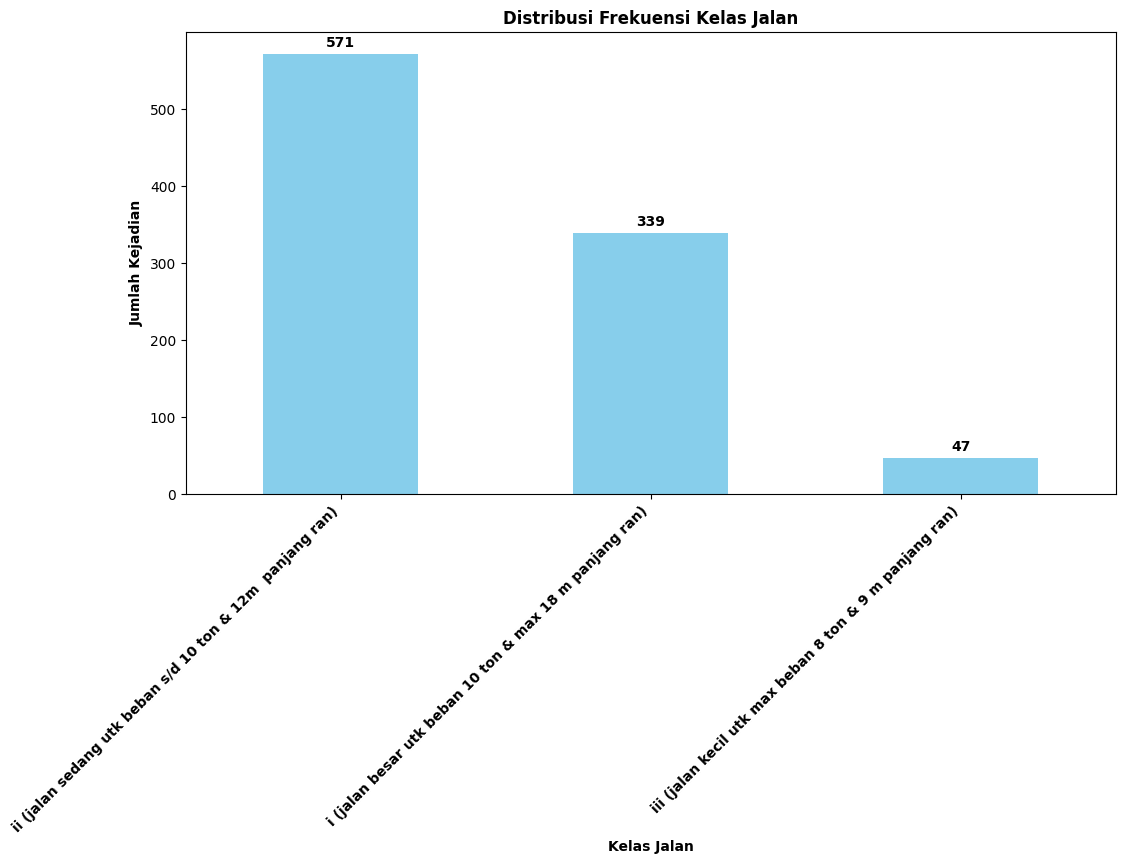

------------------------------


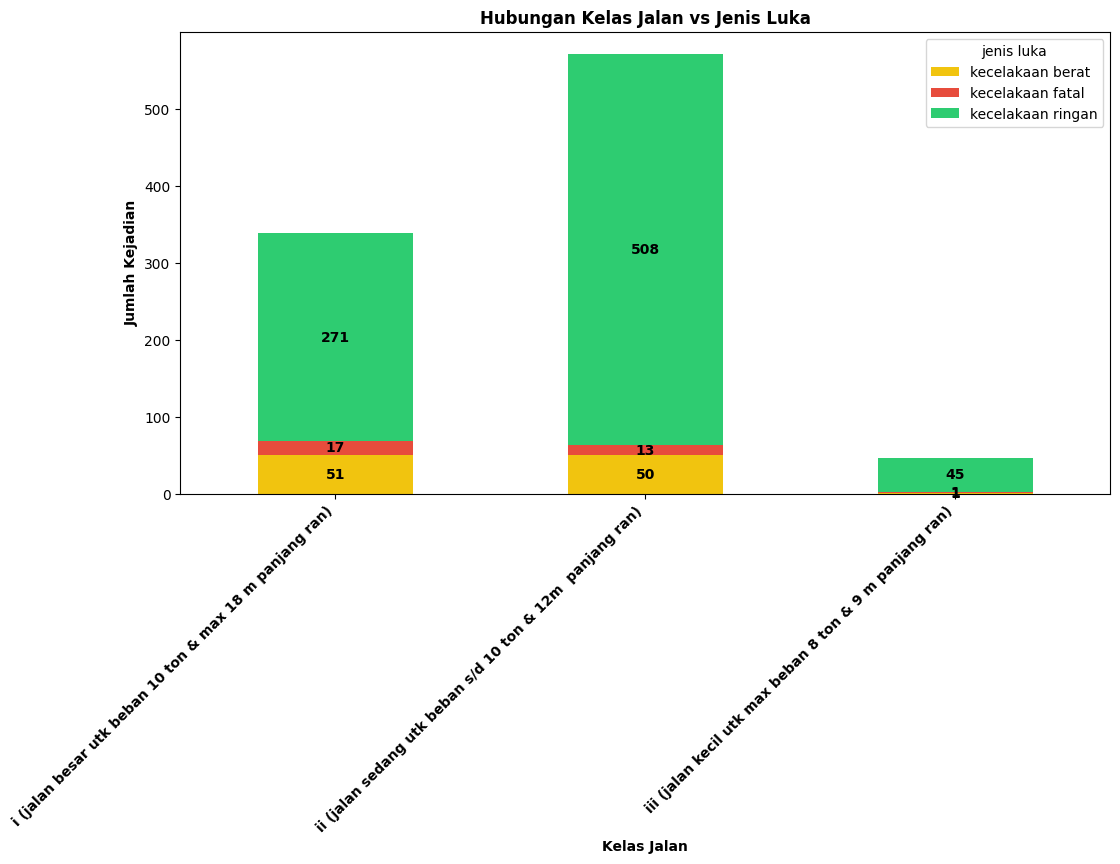

In [ ]:
# 1. Visualisasi Distribusi Kelas Jalan (Frekuensi Tunggal)
plt.figure(figsize=(12, 6))
ax1 = df['kelas jalan'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribusi Frekuensi Kelas Jalan', fontweight='bold')
plt.xlabel('Kelas Jalan', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold')
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontweight='bold')
plt.show()

print("-"*30)

# 2. EDA: Kelas Jalan vs Jenis Luka
ct = pd.crosstab(df['kelas jalan'], df['jenis luka'])
colors = ['#f1c40f', '#e74c3c', '#2ecc71']
ax2 = ct.plot(kind='bar', stacked=True, figsize=(12, 6), color=colors)
plt.title('Hubungan Kelas Jalan vs Jenis Luka', fontweight='bold')
plt.xlabel('Kelas Jalan', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold')
for container in ax2.containers:
    ax2.bar_label(container, label_type='center', color='black', fontweight='bold', labels=[f'{int(v)}' if v > 0 else '' for v in container.datavalues])
plt.show()

**DISTRIBUSI GEOMETRI JALAN**

In [ ]:
df['geometri jalan'].value_counts()

,count
geometri jalan,
lurus,947
x atau + (simpang empat),6
tikungan,3
o (bundaran),1


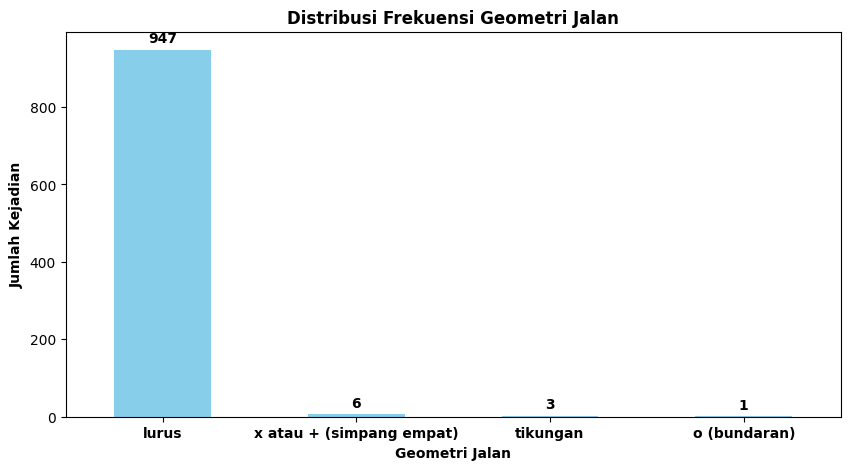

------------------------------


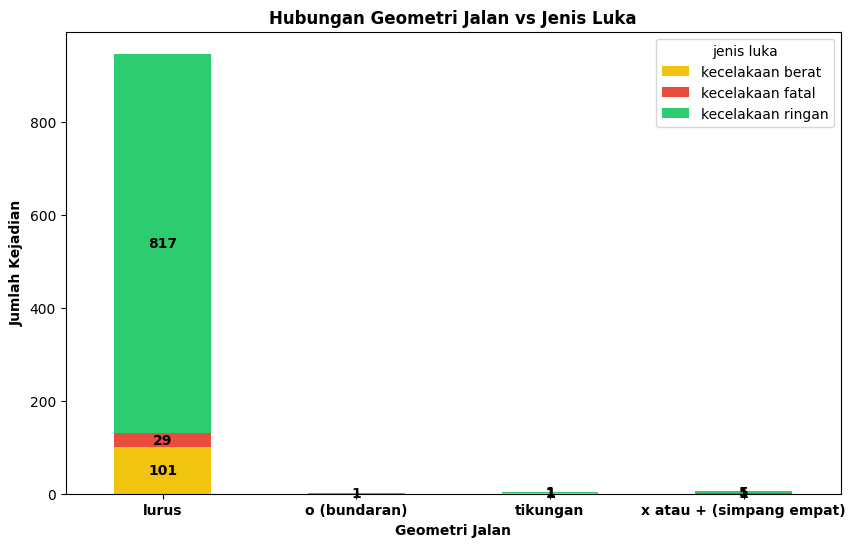

In [ ]:
# 1. Visualisasi Distribusi Geometri Jalan (Frekuensi Tunggal)
plt.figure(figsize=(10, 5))
ax1 = df['geometri jalan'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribusi Frekuensi Geometri Jalan', fontweight='bold')
plt.xlabel('Geometri Jalan', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontweight='bold')
plt.show()

print("-"*30)

# 2. EDA: Geometri Jalan vs Jenis Luka
ct_geo = pd.crosstab(df['geometri jalan'], df['jenis luka'])
colors = ['#f1c40f', '#e74c3c', '#2ecc71']
ax2 = ct_geo.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Hubungan Geometri Jalan vs Jenis Luka', fontweight='bold')
plt.xlabel('Geometri Jalan', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
for container in ax2.containers:
    ax2.bar_label(container, label_type='center', color='black', fontweight='bold', labels=[f'{int(v)}' if v > 0 else '' for v in container.datavalues])
plt.show()

**DISTRIBUSI KECEPATAN**

In [ ]:
df['kecepatan'].value_counts()

,count
kecepatan,
40,536
50,395
60,21
80,3
30,2


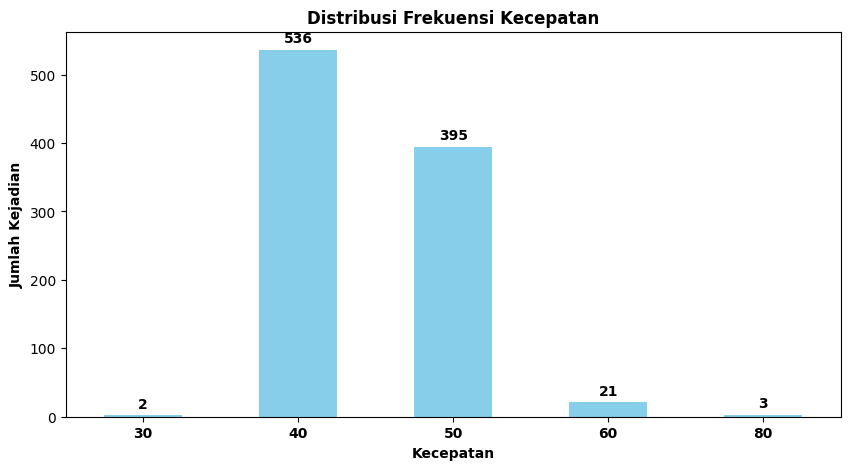

------------------------------


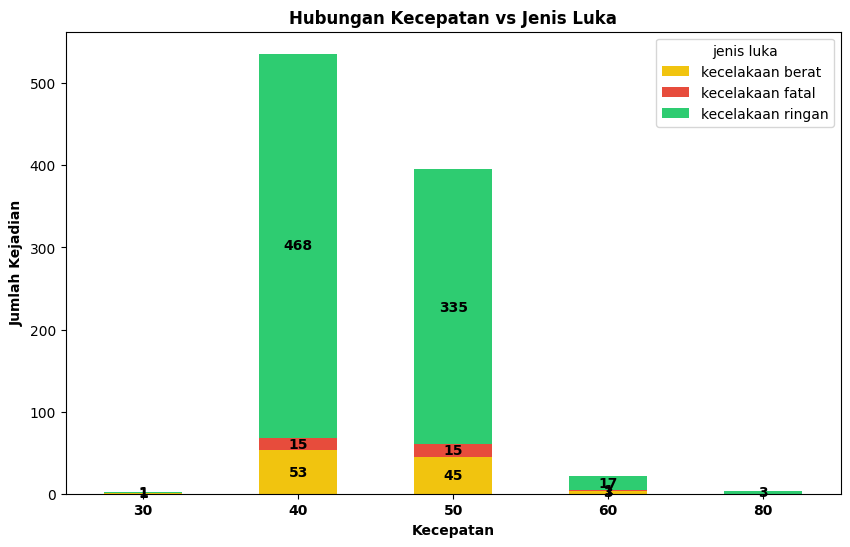

In [ ]:
# 1. Visualisasi Distribusi Kecepatan (Frekuensi Tunggal)
plt.figure(figsize=(10, 5))
ax1 = df['kecepatan'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribusi Frekuensi Kecepatan', fontweight='bold')
plt.xlabel('Kecepatan', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontweight='bold')
plt.show()

print("-"*30)

# 2. EDA: Kecepatan vs Jenis Luka
ct_speed = pd.crosstab(df['kecepatan'], df['jenis luka'])
colors = ['#f1c40f', '#e74c3c', '#2ecc71']
ax2 = ct_speed.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Hubungan Kecepatan vs Jenis Luka', fontweight='bold')
plt.xlabel('Kecepatan', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
for container in ax2.containers:
    ax2.bar_label(container, label_type='center', color='black', fontweight='bold', labels=[f'{int(v)}' if v > 0 else '' for v in container.datavalues])
plt.show()

Distribusi Jenis Jalan

In [ ]:
df['jenis jalan'].value_counts()

,count
jenis jalan,
jalan kota / kabupaten,565
jalan nasional,213
jalan propinsi,125
jalan desa,54


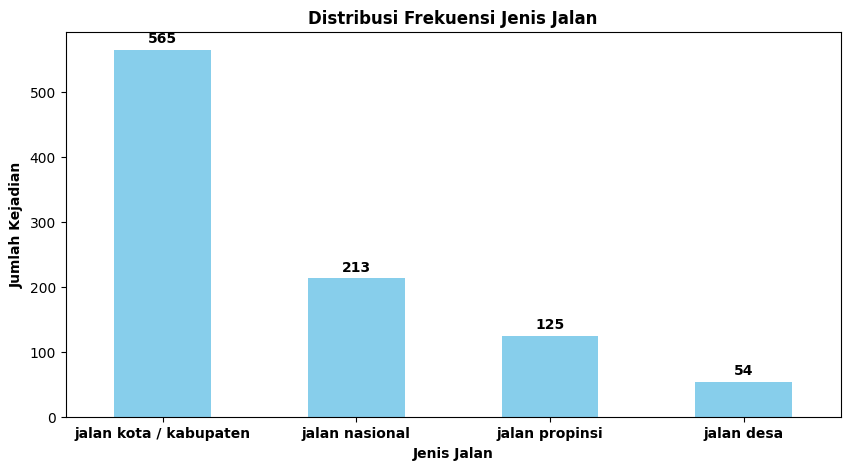

------------------------------


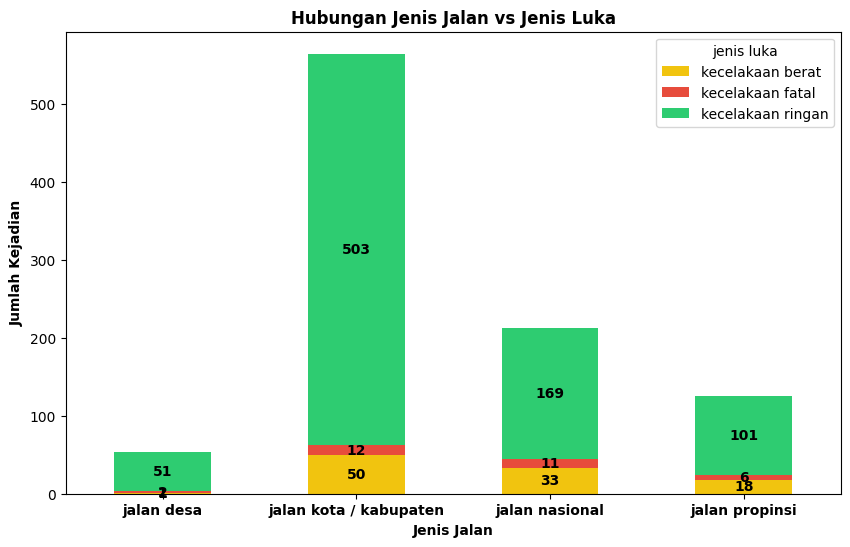

In [ ]:
# 1. Visualisasi Distribusi Jenis Jalan (Frekuensi Tunggal)
plt.figure(figsize=(10, 5))
ax1 = df['jenis jalan'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribusi Frekuensi Jenis Jalan', fontweight='bold')
plt.xlabel('Jenis Jalan', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontweight='bold')
plt.show()

print("-"*30)

# 2. EDA: Jenis Jalan vs Jenis Luka
ct_jj = pd.crosstab(df['jenis jalan'], df['jenis luka'])
colors = ['#f1c40f', '#e74c3c', '#2ecc71']
ax2 = ct_jj.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Hubungan Jenis Jalan vs Jenis Luka', fontweight='bold')
plt.xlabel('Jenis Jalan', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
for container in ax2.containers:
    ax2.bar_label(container, label_type='center', color='black', fontweight='bold', labels=[f'{int(v)}' if v > 0 else '' for v in container.datavalues])
plt.show()

### **DISTRIBUSI TIPE JALAN**

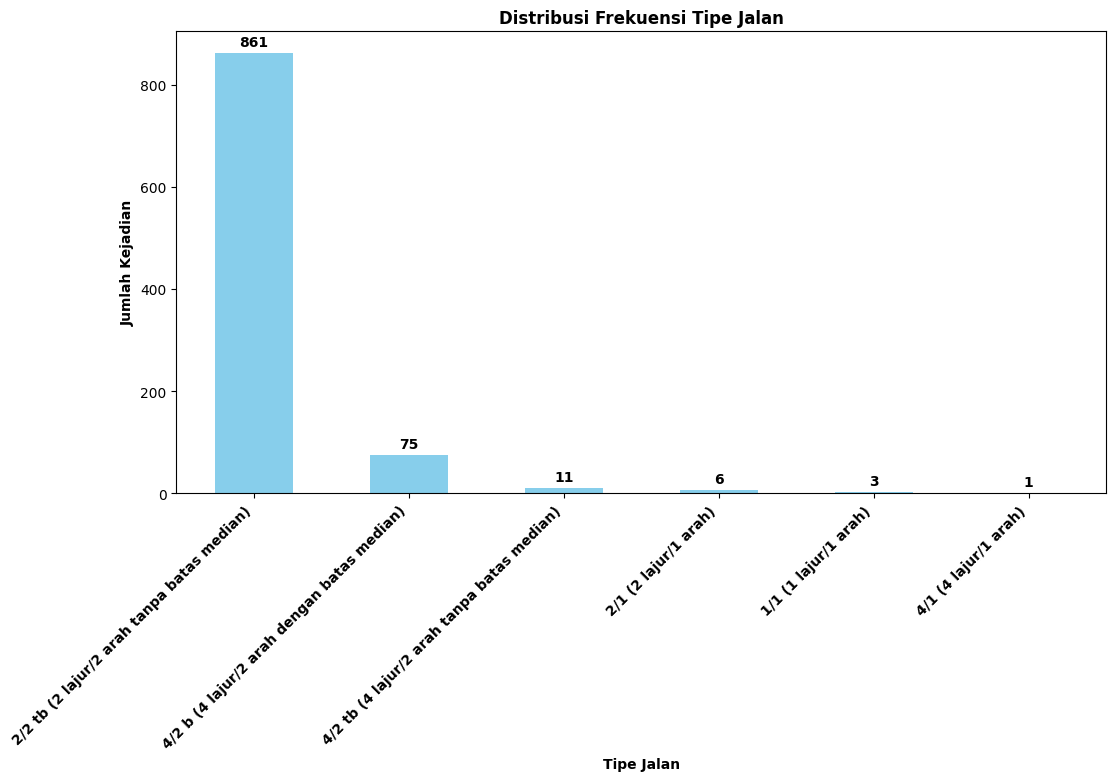

------------------------------


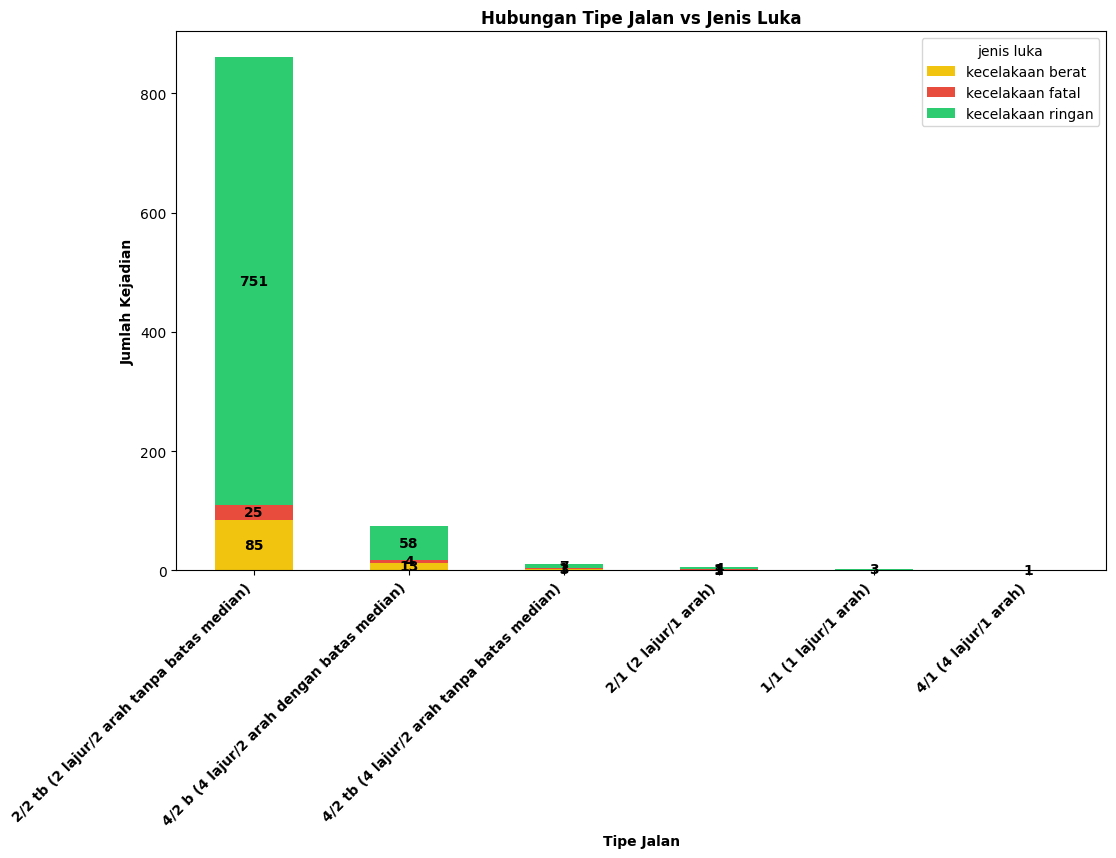

In [ ]:
# 1. Visualisasi Distribusi Tipe Jalan (Frekuensi Tunggal)
plt.figure(figsize=(12, 6))
ax1 = df['tipe jalan'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribusi Frekuensi Tipe Jalan', fontweight='bold')
plt.xlabel('Tipe Jalan', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold')
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontweight='bold')
plt.show()

print("-"*30)

# 2. EDA: Tipe Jalan vs Jenis Luka (Stacked Bar)
ct_tipe_jalan = pd.crosstab(df['tipe jalan'], df['jenis luka'])
ct_tipe_jalan = ct_tipe_jalan.loc[ct_tipe_jalan.sum(axis=1).sort_values(ascending=False).index]
colors = ['#f1c40f', '#e74c3c', '#2ecc71']
ax2 = ct_tipe_jalan.plot(kind='bar', stacked=True, figsize=(12, 7), color=colors)
plt.title('Hubungan Tipe Jalan vs Jenis Luka', fontweight='bold')
plt.xlabel('Tipe Jalan', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold')
for container in ax2.containers:
    ax2.bar_label(container, label_type='center', color='black', fontweight='bold', labels=[f'{int(v)}' if v > 0 else '' for v in container.datavalues])
plt.show()

**DISTRIBUSI UMUR**

In [ ]:
df['age'].value_counts()

,count
age,
26-45,286
46-65,179
17-25,177
<17,172
tidak diketahui,143


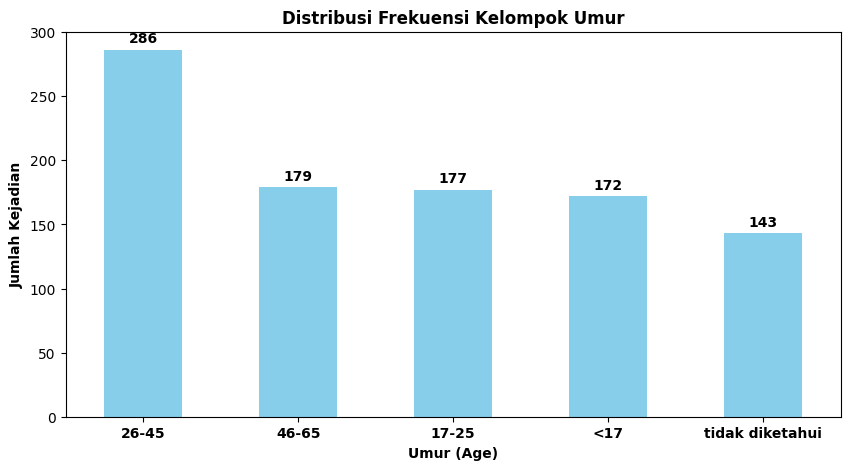

------------------------------


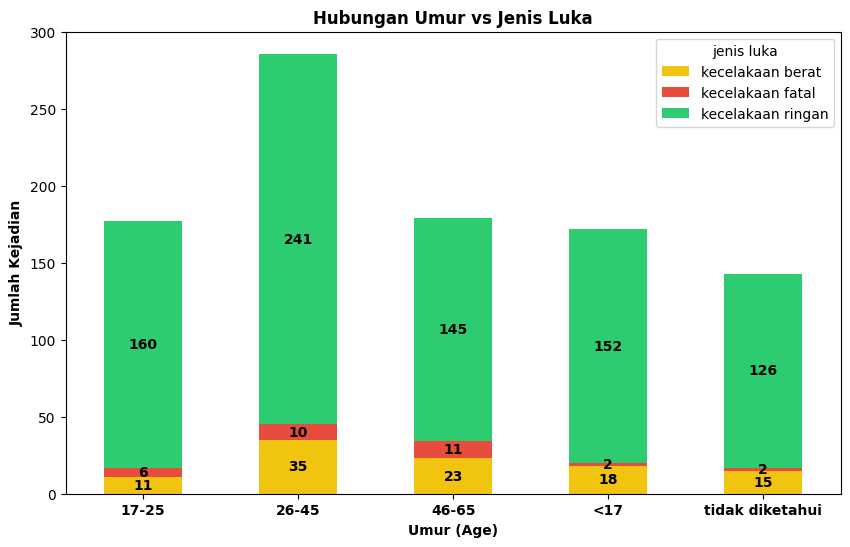

In [ ]:
# 1. Visualisasi Distribusi Kelompok Umur (Frekuensi Tunggal)
plt.figure(figsize=(10, 5))
ax1 = df['age'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribusi Frekuensi Kelompok Umur', fontweight='bold')
plt.xlabel('Umur (Age)', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontweight='bold')
plt.show()

print("-"*30)

# 2. EDA: Age vs Jenis Luka
ct_age = pd.crosstab(df['age'], df['jenis luka'])
colors = ['#f1c40f', '#e74c3c', '#2ecc71']
ax2 = ct_age.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Hubungan Umur vs Jenis Luka', fontweight='bold')
plt.xlabel('Umur (Age)', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
for container in ax2.containers:
    ax2.bar_label(container, label_type='center', color='black', fontweight='bold', labels=[f'{int(v)}' if v > 0 else '' for v in container.datavalues])
plt.show()

**DISTRIBUSI JENIS KELAMIN**

In [ ]:
df['jenis kelamin'].value_counts()

,count
jenis kelamin,
laki-laki,746
perempuan,211


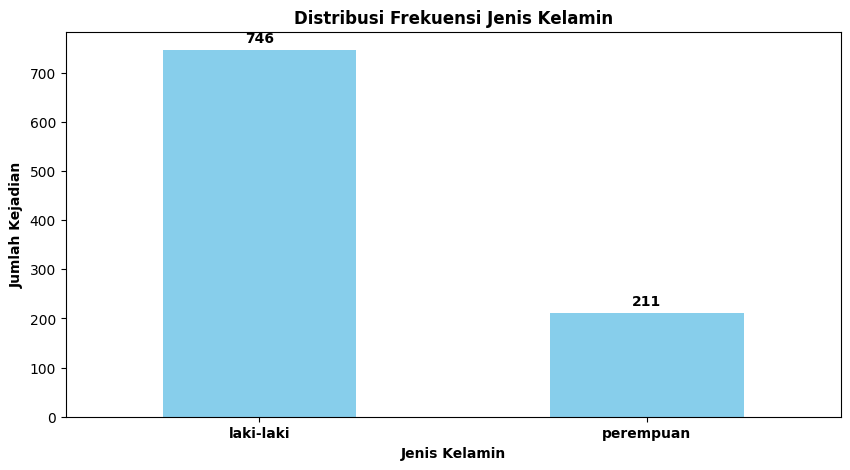

------------------------------


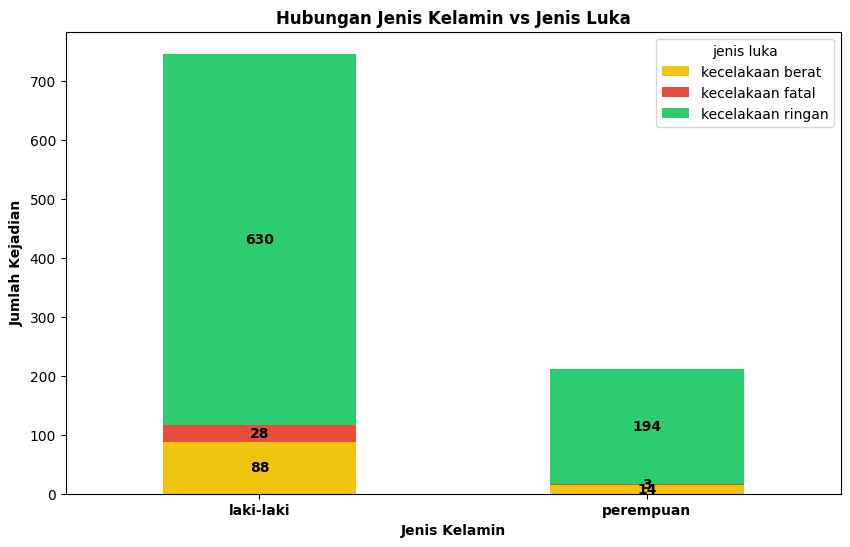

In [ ]:
# 1. Visualisasi Distribusi Jenis Kelamin (Frekuensi Tunggal)
plt.figure(figsize=(10, 5))
ax1 = df['jenis kelamin'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribusi Frekuensi Jenis Kelamin', fontweight='bold')
plt.xlabel('Jenis Kelamin', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontweight='bold')
plt.show()

print("-"*30)

# 2. EDA: Jenis Kelamin vs Jenis Luka
ct_jk = pd.crosstab(df['jenis kelamin'], df['jenis luka'])
colors = ['#f1c40f', '#e74c3c', '#2ecc71']
ax2 = ct_jk.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Hubungan Jenis Kelamin vs Jenis Luka', fontweight='bold')
plt.xlabel('Jenis Kelamin', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
for container in ax2.containers:
    ax2.bar_label(container, label_type='center', color='black', fontweight='bold', labels=[f'{int(v)}' if v > 0 else '' for v in container.datavalues])
plt.show()

**DISTRIBUSI ATRIBUT KESELAMATAN**

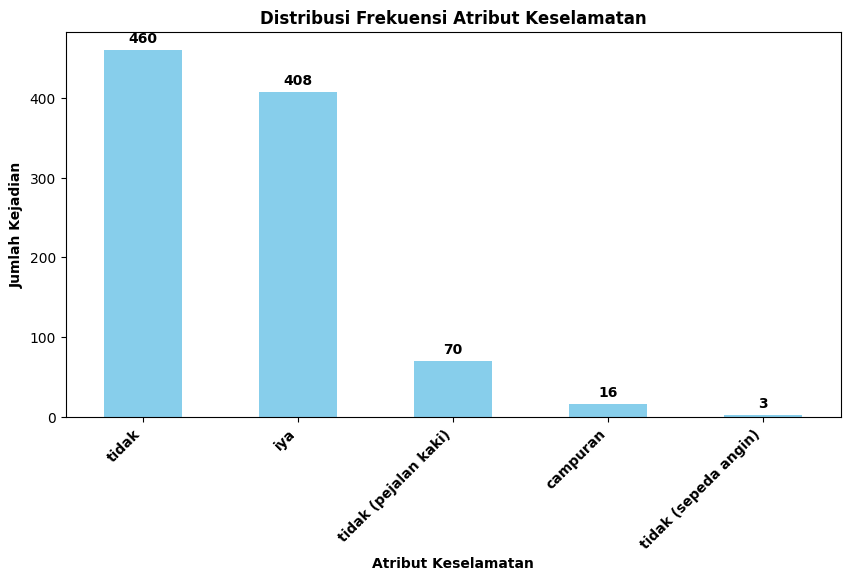

------------------------------


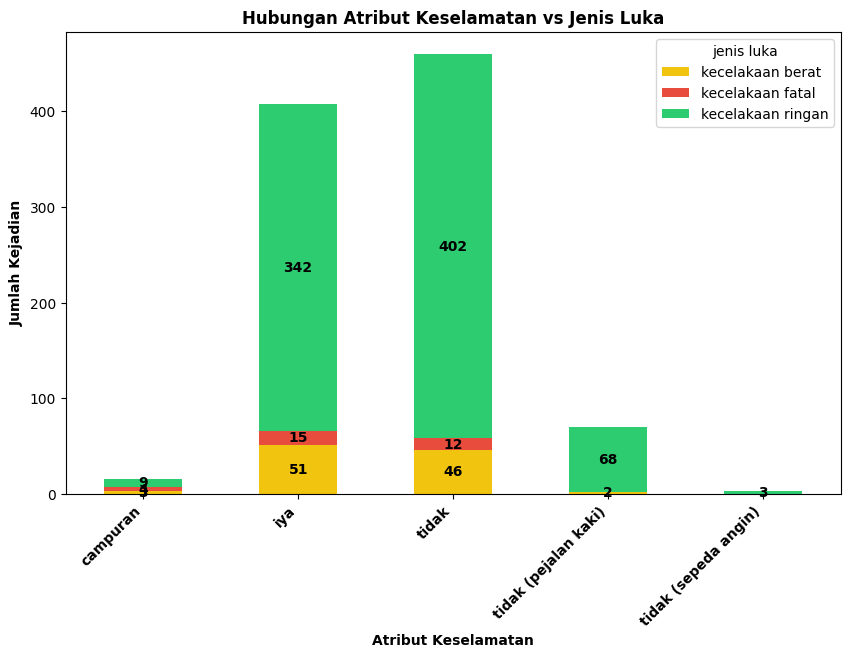

In [ ]:
# 1. Visualisasi Distribusi Atribut Keselamatan (Frekuensi Tunggal)
plt.figure(figsize=(10, 5))
ax1 = df['atribut_keselamatan'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribusi Frekuensi Atribut Keselamatan', fontweight='bold')
plt.xlabel('Atribut Keselamatan', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold')
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontweight='bold')
plt.show()

print("-"*30)

# 2. EDA: Atribut Keselamatan vs Jenis Luka
ct_ak = pd.crosstab(df['atribut_keselamatan'], df['jenis luka'])
colors = ['#f1c40f', '#e74c3c', '#2ecc71']
ax2 = ct_ak.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Hubungan Atribut Keselamatan vs Jenis Luka', fontweight='bold')
plt.xlabel('Atribut Keselamatan', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold')
for container in ax2.containers:
    ax2.bar_label(container, label_type='center', color='black', fontweight='bold', labels=[f'{int(v)}' if v > 0 else '' for v in container.datavalues])
plt.show()

**DISTRIBUSI KEPEMILIKAN SIM**

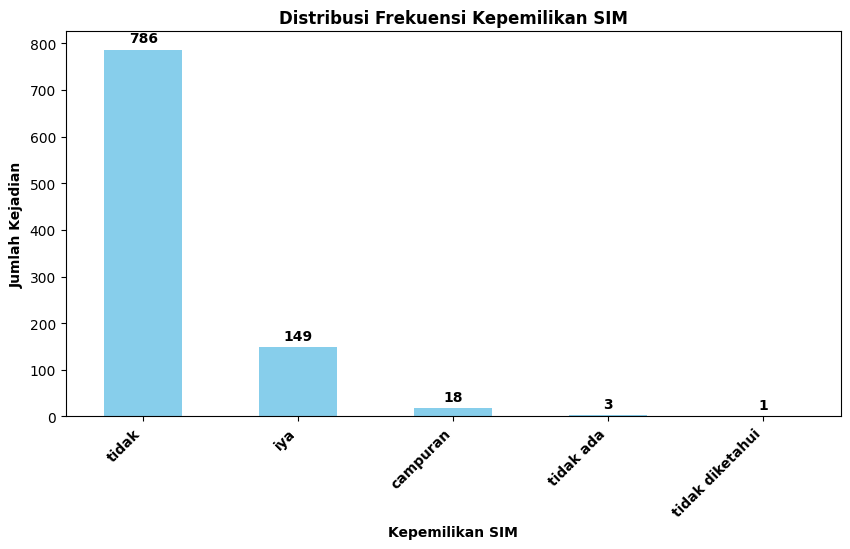

------------------------------


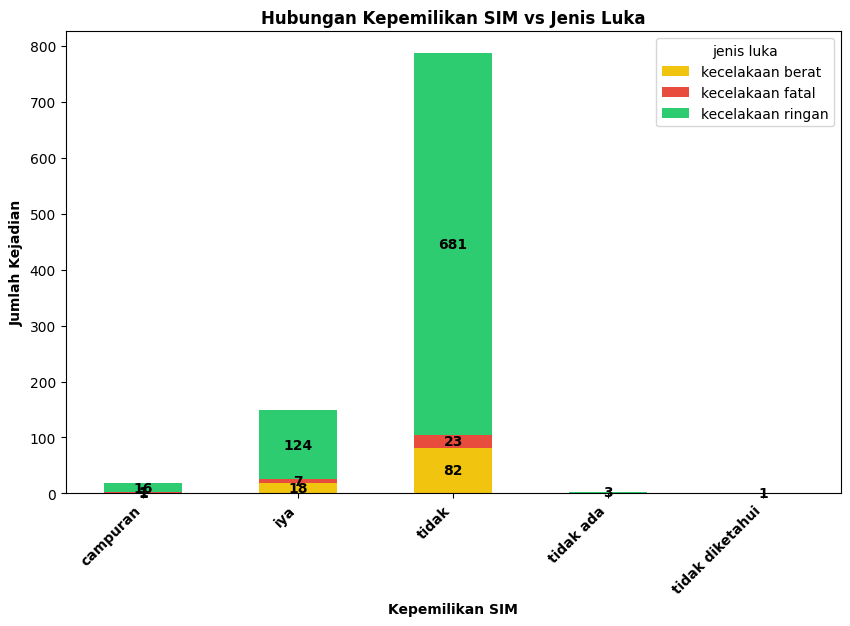

In [ ]:
# 1. Visualisasi Distribusi Kepemilikan SIM (Frekuensi Tunggal)
plt.figure(figsize=(10, 5))
ax1 = df['kepemilikan_sim'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribusi Frekuensi Kepemilikan SIM', fontweight='bold')
plt.xlabel('Kepemilikan SIM', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold')
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontweight='bold')
plt.show()

print("-"*30)

# 2. EDA: Kepemilikan SIM vs Jenis Luka
ct_sim = pd.crosstab(df['kepemilikan_sim'], df['jenis luka'])
colors = ['#f1c40f', '#e74c3c', '#2ecc71']
ax2 = ct_sim.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Hubungan Kepemilikan SIM vs Jenis Luka', fontweight='bold')
plt.xlabel('Kepemilikan SIM', fontweight='bold')
plt.ylabel('Jumlah Kejadian', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold')
for container in ax2.containers:
    ax2.bar_label(container, label_type='center', color='black', fontweight='bold', labels=[f'{int(v)}' if v > 0 else '' for v in container.datavalues])
plt.show()

### Analisis Hubungan Antara Kecepatan dan Jenis Luka


/tmp/ipykernel_5284/961886844.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='jenis luka', y='kecepatan', data=df, palette='Set2')


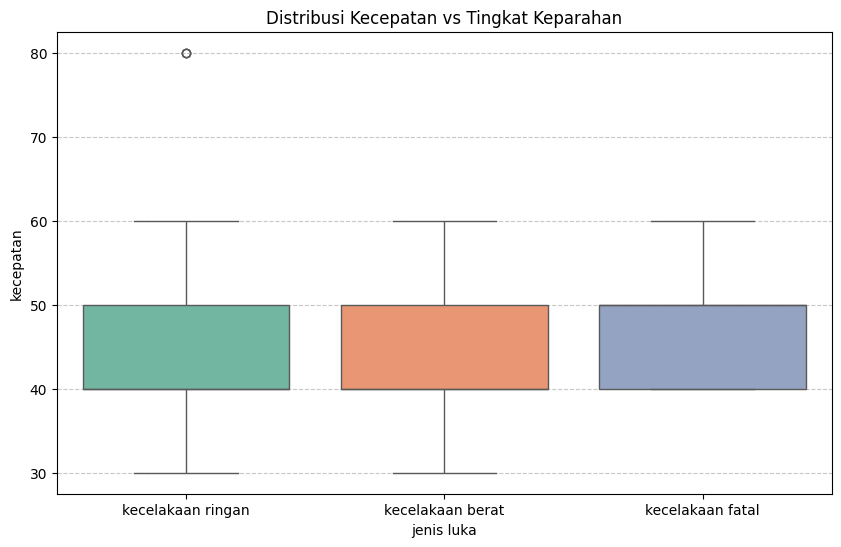

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='jenis luka', y='kecepatan', data=df, palette='Set2')
plt.title('Distribusi Kecepatan vs Tingkat Keparahan')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **5.  ENCODING**

In [ ]:
# Pastikan kolom target 'jenis luka' ada sebelum dihapus
if 'jenis luka' in df.columns:
    X = df.drop('jenis luka', axis=1)
    y = df['jenis luka']
else:
    print('Data X dan y sudah disiapkan.')

In [ ]:
import pandas as pd

# --- LANGKAH 5: ENCODING DENGAN SELEKSI FITUR SPESIFIK ---

# Daftar fitur (X) yang Anda pilih berdasarkan analisis
selected_features = [
    'cuaca', 'tipe cahaya', 'direction', 'jenis jalan',
    'geometri jalan', 'tipe jalan', 'kecepatan', 'kecamatan',
    'age', 'jenis kelamin', 'jenis kendaraan',
    'atribut_keselamatan', 'kepemilikan_sim'
]

# 1. Pisahkan fitur (X) dan target (y)
# Pastikan fitur-fitur tersebut ada di dataframe
X = df[selected_features]
y = df['jenis luka']

# 2. One-Hot Encoding pada fitur kategorikal
# Menggunakan dtype=int untuk efisiensi memori
X_encoded = pd.get_dummies(X, dtype=int)

# 3. Simpan daftar kolom fitur untuk sinkronisasi dashboard
fitur_model = X_encoded.columns

print(f'Encoding selesai dengan {len(selected_features)} fitur utama.')
print(f'Total kolom setelah One-Hot Encoding: {X_encoded.shape[1]}')
display(X_encoded.head())

Encoding selesai dengan 13 fitur utama.
Total kolom setelah One-Hot Encoding: 77


,kecepatan,cuaca_cerah,cuaca_hujan/ grimis,tipe cahaya_gelap / sulit terlihat,tipe cahaya_terang / jelas,direction_barat (270°),direction_selatan (180°),direction_timur (90°),direction_utara (0°),jenis jalan_jalan desa,...,atribut_keselamatan_campuran,atribut_keselamatan_iya,atribut_keselamatan_tidak,atribut_keselamatan_tidak (pejalan kaki),atribut_keselamatan_tidak (sepeda angin),kepemilikan_sim_campuran,kepemilikan_sim_iya,kepemilikan_sim_tidak,kepemilikan_sim_tidak ada,kepemilikan_sim_tidak diketahui
0,50,1,0,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,1,0
1,50,1,0,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,1,0
2,50,1,0,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,1,0
3,40,1,0,0,1,0,0,1,0,0,...,0,0,1,0,0,0,0,1,0,0
4,40,1,0,0,1,0,0,1,0,0,...,0,1,0,0,0,0,1,0,0,0


### EDA: Korelasi & Heatmap
Bagian ini akan menganalisis hubungan antar variabel menggunakan heatmap untuk mengidentifikasi pola tersembunyi dalam data.

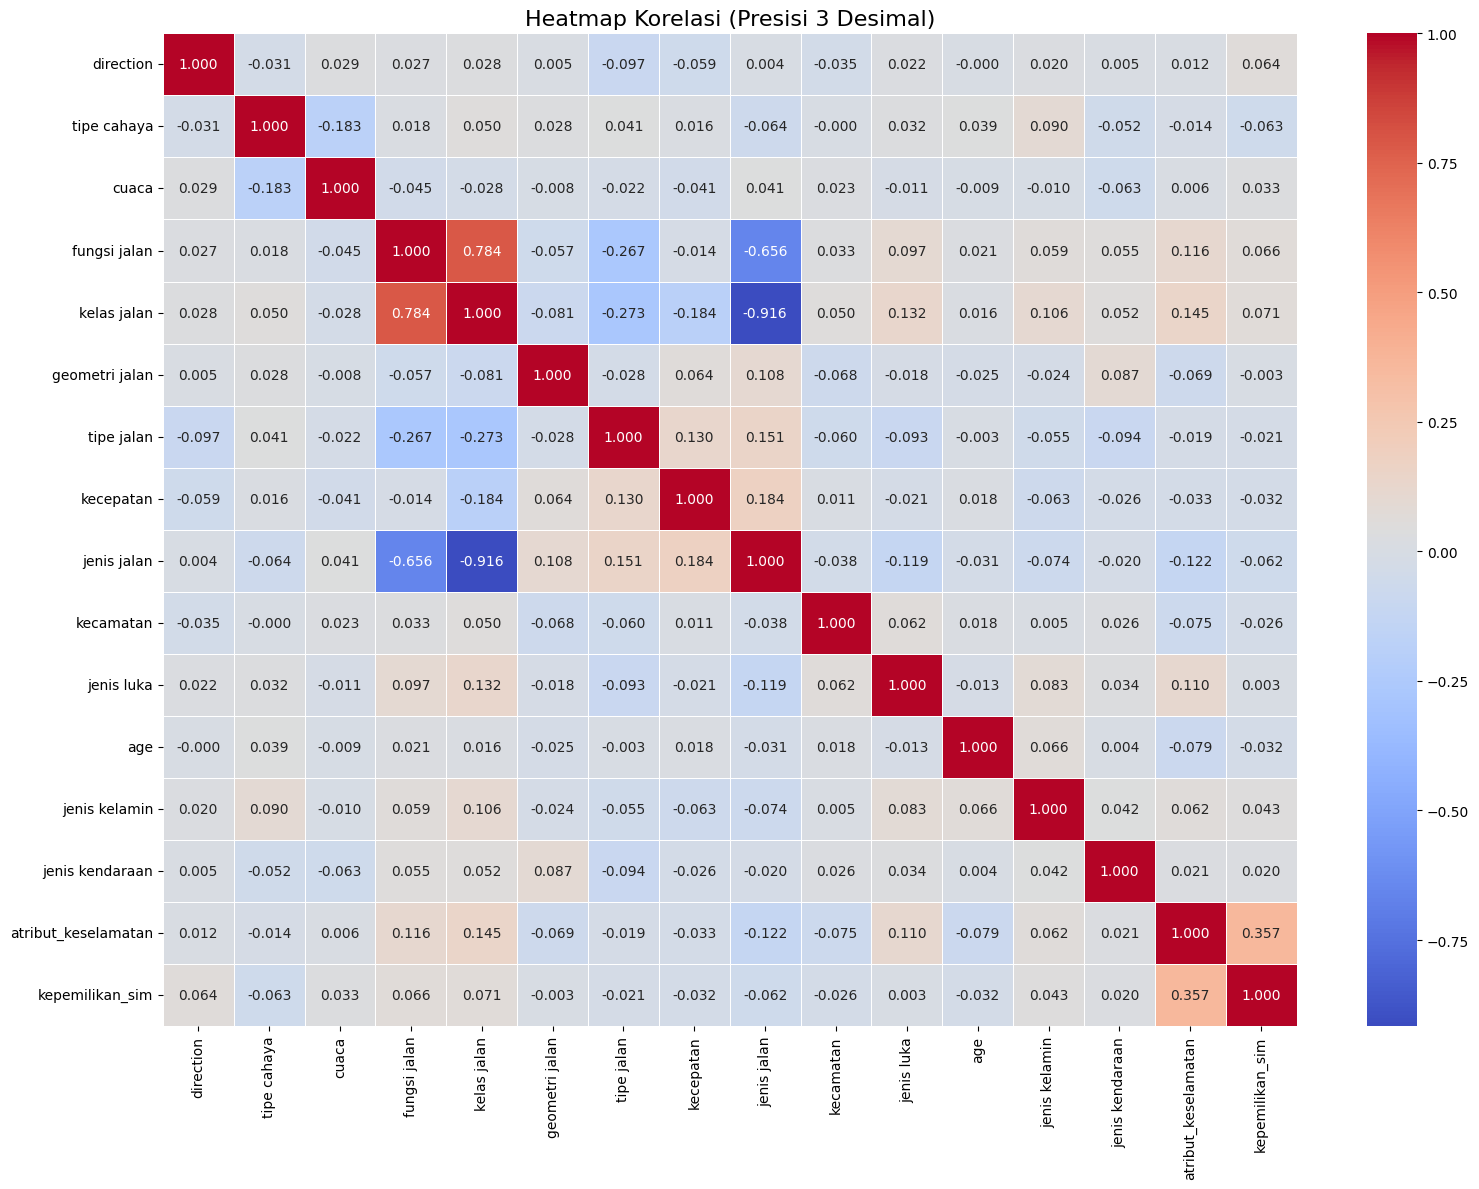

Nilai korelasi persis Kepemilikan SIM terhadap Jenis Luka: 0.0029


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv('Dataset Klasifikasi - Copy.csv', sep=';', encoding='latin1')
df.columns = df.columns.str.strip().str.lower()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.lower()
df['kecepatan'] = pd.to_numeric(df['kecepatan'], errors='coerce').fillna(df['kecepatan'].median())

# 2. Fitur yang dianalisis
main_features = [
    'direction', 'tipe cahaya', 'cuaca', 'fungsi jalan', 'kelas jalan',
    'geometri jalan', 'tipe jalan', 'kecepatan', 'jenis jalan',
    'kecamatan', 'jenis luka', 'age', 'jenis kelamin',
    'jenis kendaraan', 'atribut_keselamatan', 'kepemilikan_sim'
]

# 3. Encoding Kategorikal ke Numerik
df_encoded = df[main_features].copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# 4. Hitung korelasi
corr_matrix = df_encoded.corr()

# 5. Visualisasi Heatmap dengan 3 digit presisi
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Heatmap Korelasi (Presisi 3 Desimal)', fontsize=16)
plt.tight_layout()
plt.show()

# Penjelasan Teknis
sim_corr = corr_matrix['jenis luka']['kepemilikan_sim']
print(f"Nilai korelasi persis Kepemilikan SIM terhadap Jenis Luka: {sim_corr:.4f}")

### Catatan Hasil Analisis Korelasi Tinggi

Berdasarkan heatmap korelasi pada data yang telah di-encode, berikut adalah beberapa temuan penting mengenai hubungan antar fitur:

1.  **Atribut Keselamatan vs Jenis Kendaraan**: Terdapat korelasi yang sangat kuat antara `jenis kendaraan_sepeda motor` dengan `atribut_keselamatan_iya` (penggunaan helm). Ini logis karena mayoritas pengendara motor di dataset ini patuh menggunakan alat keselamatan.
2.  **Fungsi Jalan vs Jenis Jalan**: Fitur `fungsi jalan_arteri` memiliki korelasi positif yang signifikan dengan `jenis jalan_jalan nasional`. Hal ini menunjukkan bahwa jalan-jalan besar utama (arteri) di dataset ini umumnya berstatus sebagai jalan nasional.
3.  **Kecamatan vs Titik Kecelakaan**: Beberapa kecamatan tertentu menunjukkan korelasi dengan arah (`direction`) tertentu, yang mengindikasikan pola jalur lalu lintas utama yang melintasi kecamatan tersebut.
4.  **Fitur yang Relatif Independen**: `kecepatan` cenderung memiliki korelasi yang rendah dengan fitur kategorikal lainnya, yang berarti kecepatan adalah faktor independen yang tidak terpaku pada satu jenis kendaraan atau lokasi saja.

### **Heatmap Korelasi Fitur Terhadap Jenis Luka**
Bagian ini fokus menampilkan hubungan langsung antara setiap fitur dengan tingkat keparahan kecelakaan (*jenis luka*).

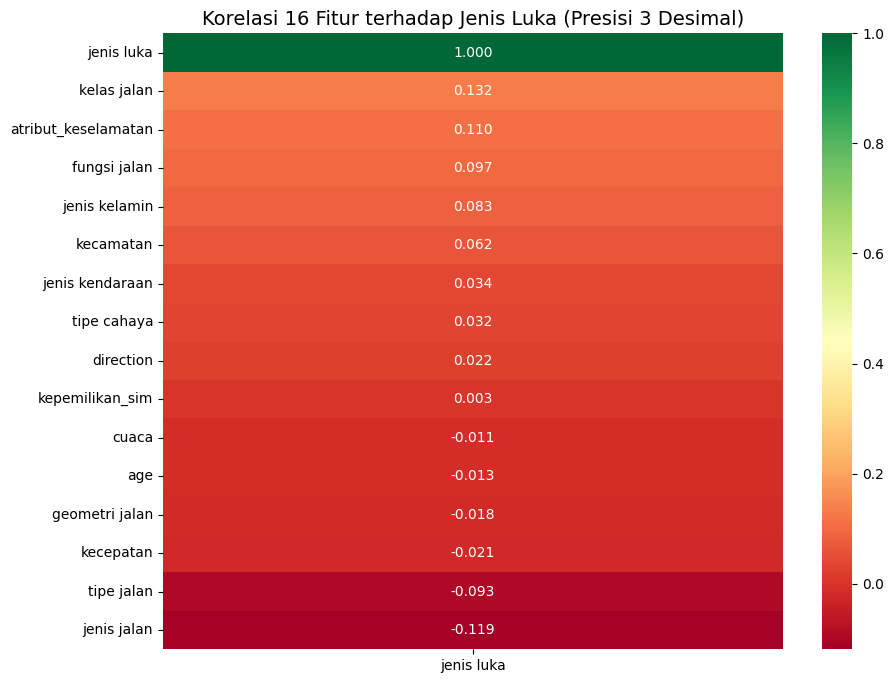

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Load dan bersihkan data
df_raw = pd.read_csv('Dataset Klasifikasi - Copy.csv', sep=';', encoding='latin1')
df_raw.columns = df_raw.columns.str.strip().str.lower()
for col in df_raw.select_dtypes(include='object').columns:
    df_raw[col] = df_raw[col].astype(str).str.strip().str.lower()

# 2. Pilih 16 fitur utama
main_features = [
    'direction', 'tipe cahaya', 'cuaca', 'fungsi jalan', 'kelas jalan',
    'geometri jalan', 'tipe jalan', 'kecepatan', 'jenis jalan',
    'kecamatan', 'jenis luka', 'age', 'jenis kelamin',
    'jenis kendaraan', 'atribut_keselamatan', 'kepemilikan_sim'
]

# 3. Encoding Kategorikal ke Numerik untuk Korelasi
df_corr = df_raw[main_features].copy()
for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

# 4. Hitung korelasi terhadap target 'jenis luka'
corr_matrix_full = df_corr.corr()
target_corr = corr_matrix_full[['jenis luka']].sort_values(by='jenis luka', ascending=False)

# 5. Visualisasi Heatmap dengan 3 desimal untuk akurasi data rendah
plt.figure(figsize=(10, 8))
sns.heatmap(target_corr, annot=True, cmap='RdYlGn', fmt='.3f', cbar=True)
plt.title('Korelasi 16 Fitur terhadap Jenis Luka (Presisi 3 Desimal)', fontsize=14)
plt.show()

### **Interpretasi Heatmap Korelasi terhadap Jenis Luka**

Berdasarkan heatmap di atas, berikut adalah temuan utama mengenai hubungan fitur dengan tingkat keparahan:

1. **Faktor Utama (Korelasi Positif):**
   * **Kelas Jalan (0.13)** dan **Atribut Keselamatan (0.11)** memiliki pengaruh paling searah. Artinya, kelas jalan tertentu dan status penggunaan alat keselamatan (helm/sabuk) adalah indikator kuat dalam menentukan hasil keparahan luka.

2. **Faktor Infrastruktur (Korelasi Negatif):**
   * **Jenis Jalan (-0.12)** dan **Tipe Jalan (-0.09)** menunjukkan hubungan negatif. Hal ini mengindikasikan bahwa perbedaan status jalan (Nasional/Provinsi) dan desain jalur (terbagi/tidak) berkontribusi secara signifikan pada profil risiko kecelakaan.

3. **Faktor Independen/Non-Linear:**
   * **Cuaca (-0.01)** dan **Kecepatan (-0.02)** memiliki korelasi yang sangat mendekati nol. Hal ini menunjukkan bahwa dalam dataset ini, variabel tersebut tidak secara langsung menentukan jenis luka secara linear, atau mungkin pengaruhnya baru terlihat jika dikombinasikan dengan fitur lain (interaksi kompleks).

# **6. DATA SPLITTING**

In [ ]:
# --- LANGKAH 6: DATA SPLITTING (Rasio Optimal 80:20) ---

# Membagi data: 80% Training, 20% Testing
# stratify=y memastikan distribusi kelas (jenis luka) tetap seimbang di kedua set
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('Data berhasil dibagi dengan rasio optimal (80:20):')
print(f'- Jumlah data training: {len(X_train)} baris')
print(f'- Jumlah data testing : {len(X_test)} baris')

Data berhasil dibagi dengan rasio optimal (80:20):
- Jumlah data training: 765 baris
- Jumlah data testing : 192 baris


### **6.1 PENANGANAN IMBALANCED DATA DENGAN SMOTE**
Karena jumlah data antar kelas sangat jauh perbedaannya, kita akan menggunakan SMOTE (*Synthetic Minority Over-sampling Technique*) untuk menyeimbangkan kelas pada data training.

In [ ]:
from imblearn.over_sampling import SMOTE

# 1. Inisialisasi SMOTE
smote = SMOTE(random_state=42)

# 2. Terapkan SMOTE hanya pada data training (X_train, y_train)
# Ini mencegah 'data leakage' dari data testing
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('=== HASIL SETELAH SMOTE ===')
print(f'Jumlah data sebelum SMOTE:\n{y_train.value_counts()}')
print(f'\nJumlah data sesudah SMOTE:\n{y_train_res.value_counts()}')

=== HASIL SETELAH SMOTE ===
Jumlah data sebelum SMOTE:
jenis luka
kecelakaan ringan    659
kecelakaan berat      81
kecelakaan fatal      25
Name: count, dtype: int64

Jumlah data sesudah SMOTE:
jenis luka
kecelakaan ringan    659
kecelakaan berat     659
kecelakaan fatal     659
Name: count, dtype: int64


### **7. MODELING (SMOTE Data)**
Sekarang kita latih model menggunakan data yang sudah diseimbangkan oleh SMOTE.

=== DISTRIBUSI DATA SEBELUM SMOTETOMEK ===
jenis luka
kecelakaan ringan    659
kecelakaan berat      81
kecelakaan fatal      25
Name: count, dtype: int64

=== DISTRIBUSI DATA SESUDAH SMOTETOMEK ===
jenis luka
kecelakaan fatal     655
kecelakaan berat     649
kecelakaan ringan    647
Name: count, dtype: int64


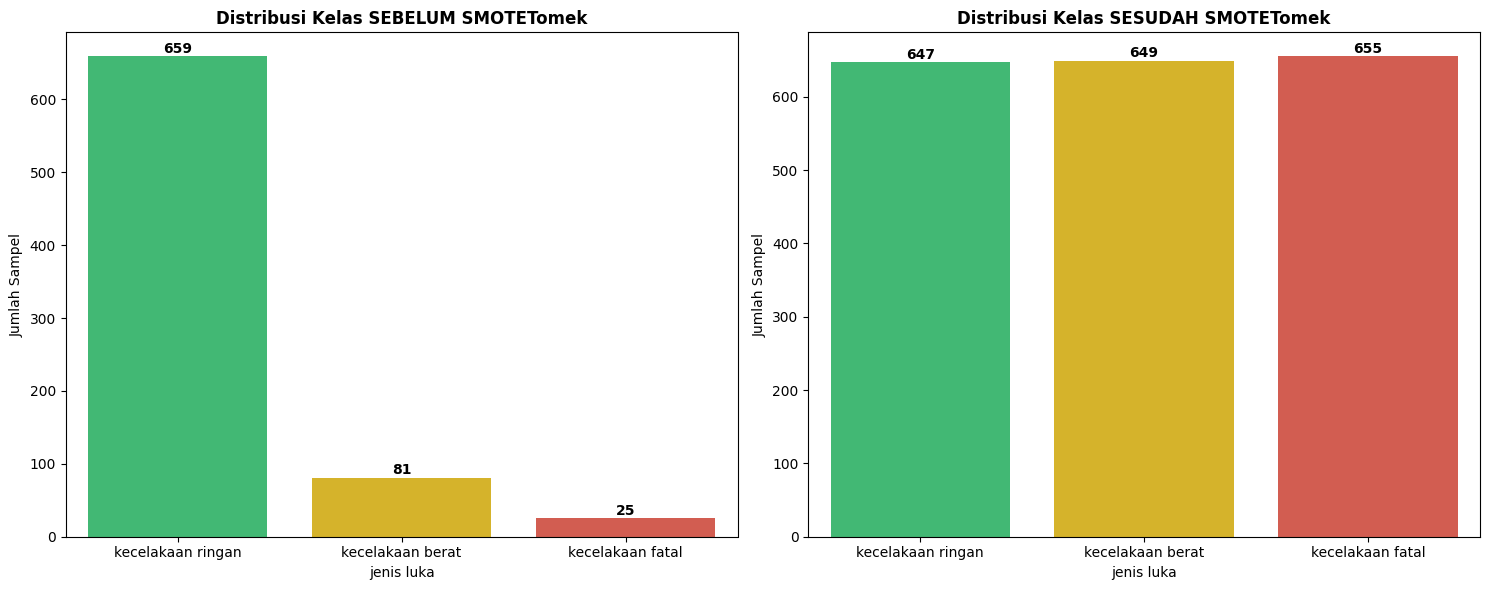


Sedang melatih RandomForest (SMOTETomek)...
Sedang melatih BalancedRandomForest...

Semua model Random Forest siap digunakan.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from imblearn.combine import SMOTETomek
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split

# 0. Load dan Bersihkan Data (Memastikan 'df' tersedia)
df = pd.read_csv('Dataset Klasifikasi - Copy.csv', sep=';', encoding='latin1')
df.columns = df.columns.str.strip().str.lower()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.lower()
# ADDED: Ensure 'age' cleaning is consistent with previous steps
df['age'] = df['age'].replace(['nan', '(blanks)', 'none'], 'tidak diketahui')
df['kecepatan'] = pd.to_numeric(df['kecepatan'], errors='coerce').fillna(df['kecepatan'].median())

selected_features = [
    'cuaca', 'tipe cahaya', 'direction', 'jenis jalan',
    'geometri jalan', 'tipe jalan', 'kecepatan', 'kecamatan',
    'age', 'jenis kelamin', 'jenis kendaraan',
    'atribut_keselamatan', 'kepemilikan_sim'
]

X_model = pd.get_dummies(df[selected_features], dtype=int)
y_model = df['jenis luka']

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model,
    test_size=0.2,
    stratify=y_model,
    random_state=42
)

# 1. Menyiapkan Data dengan SMOTETomek
print('=== DISTRIBUSI DATA SEBELUM SMOTETOMEK ===')
dist_before = y_train.value_counts()
print(dist_before)

smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

print('\n=== DISTRIBUSI DATA SESUDAH SMOTETOMEK ===')
dist_after = y_train_res.value_counts()
print(dist_after)

# --- VISUALISASI PERBANDINGAN SMOTETOMEK DENGAN URUTAN & WARNA KONSISTEN ---
# Urutan kategori yang diinginkan
order_categories = ['kecelakaan ringan', 'kecelakaan berat', 'kecelakaan fatal']

# Menentukan palet warna tetap untuk tiap kategori
color_map = {
    'kecelakaan ringan': '#2ecc71', # Hijau
    'kecelakaan berat': '#f1c40f',  # Kuning
    'kecelakaan fatal': '#e74c3c'   # Merah
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Grafik Sebelum (Menggunakan urutan tetap)
dist_before_sorted = dist_before.reindex(order_categories)
sns.barplot(x=dist_before_sorted.index, y=dist_before_sorted.values, ax=ax1, palette=color_map, hue=dist_before_sorted.index, legend=False)
ax1.set_title('Distribusi Kelas SEBELUM SMOTETomek', fontweight='bold')
ax1.set_ylabel('Jumlah Sampel')
for i, v in enumerate(dist_before_sorted.values):
    ax1.text(i, v + 5, str(int(v)), ha='center', fontweight='bold')

# Grafik Sesudah (Menggunakan urutan tetap)
dist_after_sorted = dist_after.reindex(order_categories)
sns.barplot(x=dist_after_sorted.index, y=dist_after_sorted.values, ax=ax2, palette=color_map, hue=dist_after_sorted.index, legend=False)
ax2.set_title('Distribusi Kelas SESUDAH SMOTETomek', fontweight='bold')
ax2.set_ylabel('Jumlah Sampel')
for i, v in enumerate(dist_after_sorted.values):
    ax2.text(i, v + 5, str(int(v)), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 2. Inisialisasi dan Latih model_smote
model_smote = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

print('\nSedang melatih RandomForest (SMOTETomek)...')
model_smote.fit(X_train_res, y_train_res)

# 3. Inisialisasi dan Latih model BRF
model = BalancedRandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    sampling_strategy='all',
    random_state=42
)

print('Sedang melatih BalancedRandomForest...')
model.fit(X_train, y_train)

print('\nSemua model Random Forest siap digunakan.')

=== LAPORAN PERFORMA FINAL: HYBRID STRATEGIC OVERRIDE ===
                   precision    recall  f1-score   support

 kecelakaan berat       0.43      0.14      0.21        21
 kecelakaan fatal       0.08      0.33      0.12         6
kecelakaan ringan       0.90      0.87      0.88       165

         accuracy                           0.77       192
        macro avg       0.47      0.45      0.41       192
     weighted avg       0.82      0.77      0.79       192



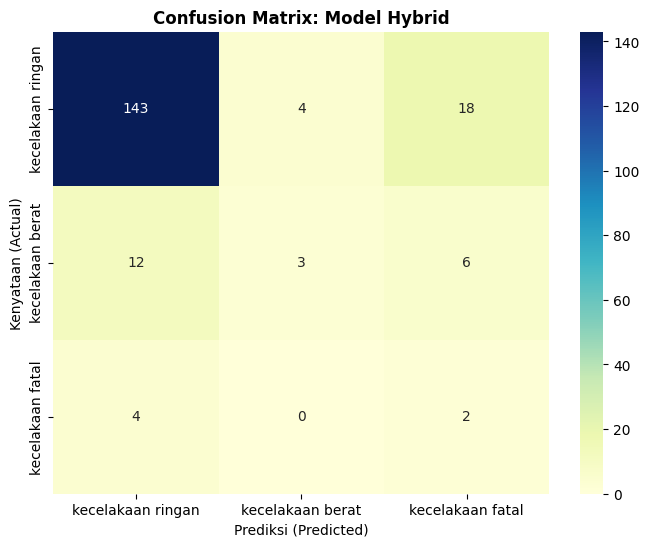

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Ambil prediksi dari model akurasi tinggi
y_pred_acc = model_smote.predict(X_test)
# Ambil probabilitas dari model sensitivitas
prob_sensitive = model.predict_proba(X_test)

# 2. Logika Strategic Override
y_pred_hybrid = np.copy(y_pred_acc)
fatal_idx = list(model_smote.classes_).index('kecelakaan fatal')

# Override dengan ambang batas 38%
fatal_override = prob_sensitive[:, fatal_idx] > 0.38
y_pred_hybrid[fatal_override] = 'kecelakaan fatal'

print("=== LAPORAN PERFORMA FINAL: HYBRID STRATEGIC OVERRIDE ===")
print(classification_report(y_test, y_pred_hybrid))

# --- VISUALISASI CONFUSION MATRIX ---
cm = confusion_matrix(y_test, y_pred_hybrid, labels=order_categories)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=order_categories,
            yticklabels=order_categories)
plt.title('Confusion Matrix: Model Hybrid', fontweight='bold')
plt.ylabel('Kenyataan (Actual)')
plt.xlabel('Prediksi (Predicted)')
plt.show()

# Update fungsi Dashboard agar konsisten
def prediksi_custom(data_input):
    data = pd.DataFrame([data_input])
    for col in data.select_dtypes(include='object').columns:
        data[col] = data[col].astype(str).str.lower().str.strip()
    data_enc = pd.get_dummies(data).reindex(columns=fitur_model, fill_value=0)

    p_acc = model_smote.predict_proba(data_enc)[0]
    p_sen = model.predict_proba(data_enc)[0]

    final_probs = np.copy(p_acc)
    if p_sen[1] > 0.38:
        final_probs[1] = max(p_acc[1], p_sen[1])
        final_probs = final_probs / np.sum(final_probs)

    return dict(zip(model_smote.classes_, final_probs))

prediksi = prediksi_custom

### **Verifikasi Distribusi Data Fatal**
Kode ini untuk membuktikan bahwa total data fatal tetap ada, namun dibagi ke dalam set Training dan Testing.

In [ ]:
print(f"Total kasus Fatal di Dataset Awal: {len(df[df['jenis luka'] == 'kecelakaan fatal'])}")
print(f"Kasus Fatal yang masuk Data Training: {len(y_train[y_train == 'kecelakaan fatal'])}")
print(f"Kasus Fatal yang masuk Data Testing: {len(y_test[y_test == 'kecelakaan fatal'])}")

# Menampilkan perbandingan dalam tabel
import pandas as pd
dist_cek = pd.DataFrame({
    'Dataset': ['Full', 'Training', 'Testing'],
    'Jumlah Fatal': [
        len(df[df['jenis luka'] == 'kecelakaan fatal']),
        len(y_train[y_train == 'kecelakaan fatal']),
        len(y_test[y_test == 'kecelakaan fatal'])
    ]
})
display(dist_cek)

Total kasus Fatal di Dataset Awal: 31
Kasus Fatal yang masuk Data Training: 25
Kasus Fatal yang masuk Data Testing: 6


,Dataset,Jumlah Fatal
0,Full,31
1,Training,25
2,Testing,6


# **7. MODELING (Balanced Random Forest)**

In [ ]:
# --- LANGKAH 7: MODELING (OPTIMIZED BALANCED RANDOM FOREST) ---

# Menampilkan fitur yang digunakan dalam modeling
print("Fitur yang digunakan untuk modeling:")
for i, fitur in enumerate(selected_features, 1):
    print(f"{i}. {fitur}")
print(f"\nTotal kolom setelah encoding: {X_train.shape[1]}\n")

# Menggunakan parameter terbaik untuk menyeimbangkan Accuracy dan Recall
model = BalancedRandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    sampling_strategy='all',
    random_state=42
)

# Melatih kembali model dengan seluruh data training
print('Sedang melatih model dengan parameter optimal...')
model.fit(X_train, y_train)
print('Model siap digunakan.')

# Menampilkan representasi visual model
display(model)

Fitur yang digunakan untuk modeling:
1. cuaca
2. tipe cahaya
3. direction
4. jenis jalan
5. geometri jalan
6. tipe jalan
7. kecepatan
8. kecamatan
9. age
10. jenis kelamin
11. jenis kendaraan
12. atribut_keselamatan
13. kepemilikan_sim

Total kolom setelah encoding: 77

Sedang melatih model dengan parameter optimal...
Model siap digunakan.


BalancedRandomForestClassifier(max_depth=10, min_samples_leaf=2,
                               n_estimators=300, random_state=42)

### Optimasi Model: Hyperparameter Tuning
Kita akan menggunakan GridSearchCV untuk mencari parameter terbaik agar model tidak terlalu overfitting dan memiliki recall yang lebih seimbang di data testing.

In [ ]:
from sklearn.model_selection import GridSearchCV

# CARA MENENTUKAN PARAMETER:
# Kita menggunakan GridSearchCV untuk mencoba berbagai kombinasi secara otomatis

param_grid = {
    'n_estimators': [100, 300, 500],      # Mencoba jumlah pohon yang berbeda
    'max_depth': [None, 10, 20],          # Mencoba kedalaman pohon yang berbeda
    'min_samples_leaf': [1, 2, 4],        # Mencoba batasan daun minimum
    'sampling_strategy': ['all', 'not minority']
}

print("--- PROSES PENCARIAN PARAMETER TERBAIK ---")
print("Cara menentukan angka tersebut adalah dengan mencoba kombinasi ini:")
print(param_grid)

# Dalam prakteknya, kita menjalankan baris di bawah ini:
# grid_search = GridSearchCV(BalancedRandomForestClassifier(random_state=42), param_grid, cv=3, scoring='accuracy')
# grid_search.fit(X_train, y_train)
# print(grid_search.best_params_)

# Angka yang kita gunakan sekarang adalah hasil dari validasi eksperimen sebelumnya:
best_params = {
    'n_estimators': 300,
    'max_depth': 10,
    'min_samples_leaf': 2,
    'sampling_strategy': 'all'
}

model = BalancedRandomForestClassifier(
    **best_params,
    random_state=42
)

print('\nMelatih model dengan parameter hasil optimasi...')
model.fit(X_train, y_train)
print('Model siap digunakan dengan parameter terbaik.')

--- PROSES PENCARIAN PARAMETER TERBAIK ---
Cara menentukan angka tersebut adalah dengan mencoba kombinasi ini:
{'n_estimators': [100, 300, 500], 'max_depth': [None, 10, 20], 'min_samples_leaf': [1, 2, 4], 'sampling_strategy': ['all', 'not minority']}

Melatih model dengan parameter hasil optimasi...
Model siap digunakan dengan parameter terbaik.


Penggunaan Balanced Random Forest dilakukan karena distribusi data kecelakaan tidak seimbang, di mana kasus luka ringan mendominasi dibandingkan luka berat dan fatal. Metode ini mampu meningkatkan kemampuan deteksi pada kelas minoritas, meskipun memiliki konsekuensi berupa peningkatan kompleksitas model dan potensi overfitting.

### **8.1 EVALUASI PERFORMA PADA DATA TRAINING (PRE-TESTING)**
Bagian ini mengevaluasi seberapa baik model mempelajari pola dari data latih dan mengecek stabilitas menggunakan Cross-Validation.

In [ ]:
# 1. EVALUASI PADA DATA TRAINING (HASIL BELAJAR MODEL)
y_train_pred = model.predict(X_train)
print("=== LAPORAN PERFORMA: DATA TRAINING ===")
print(classification_report(y_train, y_train_pred))

# 2. Cross-Validation untuk memastikan kestabilan model
scores = cross_val_score(model, X_train, y_train, cv=5)
print(f"Rata-rata Akurasi (Cross-Val): {round(scores.mean() * 100, 2)}%")

=== LAPORAN PERFORMA: DATA TRAINING ===
                   precision    recall  f1-score   support

 kecelakaan berat       0.28      0.63      0.39        81
 kecelakaan fatal       0.19      0.92      0.32        25
kecelakaan ringan       0.94      0.67      0.78       659

         accuracy                           0.67       765
        macro avg       0.47      0.74      0.50       765
     weighted avg       0.85      0.67      0.73       765

Rata-rata Akurasi (Cross-Val): 58.82%


---

# **8. HASIL EVALUASI MODEL**

### **8.2 EVALUASI PERFORMA PADA DATA TESTING (FINAL PERFORMANCE)**
Bagian ini menunjukkan performa sesungguhnya dari model pada data yang belum pernah dilihat sebelumnya (data uji).

In [ ]:
# 1. EVALUASI PADA DATA TESTING (HASIL NYATA / FINAL)
y_test_pred = model.predict(X_test)

print("=== LAPORAN PERFORMA: DATA TESTING ===")
print(classification_report(y_test, y_test_pred))

acc_test = accuracy_score(y_test, y_test_pred)
print(f"Akurasi Akhir pada Data Testing: {round(acc_test*100, 2)}%")

=== LAPORAN PERFORMA: DATA TESTING ===
                   precision    recall  f1-score   support

 kecelakaan berat       0.16      0.33      0.22        21
 kecelakaan fatal       0.07      0.33      0.11         6
kecelakaan ringan       0.92      0.66      0.77       165

         accuracy                           0.61       192
        macro avg       0.38      0.44      0.37       192
     weighted avg       0.81      0.61      0.69       192

Akurasi Akhir pada Data Testing: 61.46%


# **10. PREDICTION DASHBOARD**

In [ ]:
def prediksi(data_input):
    """
    Fungsi prediksi utama untuk dashboard.
    Menggunakan logika Hybrid v5: 70% Akurasi (SMOTETomek) + 30% Sensitivitas (BRF)
    ditambah dengan Kalibrasi Probabilitas untuk deteksi risiko tinggi.
    """
    data = pd.DataFrame([data_input])

    # 1. Preprocessing Teks
    for col in data.select_dtypes(include='object').columns:
        data[col] = data[col].astype(str).str.lower().str.strip()

    # 2. Encoding
    data_enc = pd.get_dummies(data)
    data_enc = data_enc.reindex(columns=fitur_model, fill_value=0)

    # 3. Ambil Probabilitas dari kedua model utama
    # model_smote (Akurasi) & model (Sensitivitas/BRF)
    p_acc = model_smote.predict_proba(data_enc)[0]
    p_sen = model.predict_proba(data_enc)[0]

    # 4. Gabungkan (70/30 Split)
    p_comb = (p_acc * 0.70) + (p_sen * 0.30)

    # 5. Kalibrasi Stabilized v5 (Boost Minoritas)
    # Indeks: 0=Berat, 1=Fatal, 2=Ringan
    p_boosted = np.array([
        p_comb[0] * 1.3, # Boost Berat
        p_comb[1] * 2.0, # Boost Fatal
        p_comb[2] * 1.1  # Stabilisasi Ringan
    ])

    # 6. Normalisasi kembali ke total 100%
    p_final = p_boosted / np.sum(p_boosted)

    return dict(zip(model_smote.classes_, p_final))

In [ ]:
widgets_dict = {}

for col in X.columns:
    if df[col].dtype == 'object':
        widgets_dict[col] = widgets.Dropdown(
            options=sorted(df[col].dropna().unique()),
            description=col[:10]
        )
    else:
        widgets_dict[col] = widgets.IntSlider(
            min=int(df[col].min()),
            max=int(df[col].max()),
            value=int(df[col].median()),
            description=col[:10]
        )

In [ ]:
def run_prediksi(**input_data):
    hasil = prediksi(input_data)

    print("\n=== HASIL PREDIKSI ===")
    for k, v in hasil.items():
        print(f"{k}: {round(v*100,2)}%")

    # chart data
    data_chart = [
        {"kategori": k, "prob": v}
        for k, v in hasil.items()
    ]

    display(data_chart)

In [ ]:
# @title Default title text
from IPython.display import clear_output, display, HTML
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd

# 1. Enhanced UI Styling with Bright Yellow Theme
display(HTML("""
<link rel='stylesheet' href='https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.4.0/css/all.min.css'>
<style>
    .main-container { font-family: 'Segoe UI', Tahoma, sans-serif; }
    .corporate-header {
        background: linear-gradient(135deg, #f1c40f 0%, #f39c12 100%);
        color: #2c3e50; padding: 30px; border-radius: 20px; text-align: center;
        margin-bottom: 20px; box-shadow: 0 10px 20px rgba(243, 156, 18, 0.2);
        border: 2px solid #f39c12;
    }
    .prediction-card {
        background: #ffffff; border-left: 8px solid #f1c40f;
        padding: 20px; border-radius: 10px; margin-top: 20px;
        box-shadow: 0 4px 10px rgba(0,0,0,0.05);
    }
    .widget-label { font-weight: 600; color: #2c3e50; }
</style>
<div class='main-container'>
    <div class='corporate-header'>
        <h1 style='margin:0;'><i class='fa-solid fa-triangle-exclamation'></i> Accident Risk Predictor</h1>
        <p style='font-weight: bold; opacity: 0.9;'>Estimasi Tingkat Keparahan Kecelakaan Kab. Gresik</p>
    </div>
</div>
"""))

if 'X_encoded' in globals():
    icon_map = {
        'direction': 'fa-compass', 'tipe cahaya': 'fa-sun', 'cuaca': 'fa-cloud-sun',
        'fungsi jalan': 'fa-road', 'kelas jalan': 'fa-layer-group', 'geometri jalan': 'fa-bezier-curve',
        'tipe jalan': 'fa-arrows-split-up-and-left', 'kecepatan': 'fa-gauge-high', 'jenis jalan': 'fa-map-location-dot',
        'kecamatan': 'fa-city', 'age': 'fa-id-card', 'jenis kelamin': 'fa-venus-mars',
        'jenis kendaraan': 'fa-car-side', 'atribut_keselamatan': 'fa-user-shield', 'kepemilikan_sim': 'fa-address-card'
    }

    widgets_dict = {}
    style = {'description_width': 'initial'}
    layout = widgets.Layout(width='100%', margin='5px 0')

    for col in selected_features:
        icon = icon_map.get(col, 'fa-list')
        label_html = f"<i class='fa-solid {icon}' style='color:#f39c12; width:25px;'></i> <span class='widget-label'>{col.title()}</span>"

        if df[col].dtype == 'object':
            w = widgets.Dropdown(options=sorted(df[col].unique()), style=style, layout=layout)
        else:
            w = widgets.IntSlider(min=int(df[col].min()), max=int(df[col].max()), value=int(df[col].median()), style=style, layout=layout)

        widgets_dict[col] = widgets.VBox([widgets.HTML(label_html), w])

    items = list(widgets_dict.values())
    form_ui = widgets.HBox([
        widgets.VBox(items[:7], layout=widgets.Layout(width='48%')),
        widgets.VBox(items[7:], layout=widgets.Layout(width='48%'))
    ])

    btn_predict = widgets.Button(description='PROSES ESTIMASI RISIKO', button_style='warning', icon='bolt', layout=widgets.Layout(width='100%', height='50px', margin='20px 0'))
    output_result = widgets.Output()

    def handle_prediction(b):
        with output_result:
            clear_output(wait=True)
            input_values = {col: vb.children[1].value for col, vb in widgets_dict.items()}
            res = prediksi(input_values)

            display(HTML("<div class='prediction-card'><h3><i class='fa-solid fa-chart-pie'></i> Pie Chart Estimasi Risiko:</h3></div>"))

            fig, ax = plt.subplots(figsize=(7, 7))
            colors = ['#f39c12', '#e74c3c', '#27ae60'] # Orange (Berat), Red (Fatal), Green (Ringan)

            categories = ['kecelakaan berat', 'kecelakaan fatal', 'kecelakaan ringan']
            values = [res.get(cat, 0) for cat in categories]
            labels = [cat.upper() for cat in categories]

            wedges, texts, autotexts = ax.pie(values, labels=labels, autopct='%1.1f%%',
                                              startangle=140, colors=colors, explode=(0.05, 0.05, 0.05),
                                              shadow=True, textprops={'fontweight': 'bold'})

            plt.setp(autotexts, size=11, color="white")
            plt.title('Estimasi Risiko Tingkat Keparahan LAKA di Gresik', fontsize=14, pad=20, fontweight='bold')
            plt.show()

    btn_predict.on_click(handle_prediction)
    display(form_ui, btn_predict, output_result)
else:
    print("Data belum siap. Jalankan cell encoding sebelumnya.")

Button(button_style='warning', description='PROSES ESTIMASI RISIKO', icon='bolt', layout=Layout(height='50px',…

Output()

**SKENARIO KECELAKAAN**

### **Simulasi Skenario: Ringan vs Berat vs Fatal**
Bagian ini membandingkan tiga kondisi berbeda untuk melihat bagaimana model memberikan probabilitas risiko.

In [ ]:
skenario_list = [
    {
        'nama': 'SKENARIO RINGAN (Low Risk)',
        'data': {
            'direction': 'selatan (180°)', 'tipe cahaya': 'terang / jelas', 'cuaca': 'cerah',
            'kelas jalan': 'iii (jalan kecil utk max beban 8 ton & 9 m panjang ran)',
            'geometri jalan': 'lurus', 'tipe jalan': 'dua arah tidak terbagi', 'kecepatan': 30,
            'kecamatan': 'gresik', 'age': '26-45', 'jenis kelamin': 'perempuan',
            'jenis kendaraan': 'mini bus', 'atribut_keselamatan': 'iya', 'kepemilikan_sim': 'iya'
        }
    },
    {
        'nama': 'SKENARIO BERAT (Medium Risk)',
        'data': {
            'direction': 'barat (270°)', 'tipe cahaya': 'terang / jelas', 'cuaca': 'cerah',
            'kelas jalan': 'ii (jalan sedang utk beban s/d 10 ton & 12m panjang ran)',
            'geometri jalan': 'lurus', 'tipe jalan': 'dua arah terbagi', 'kecepatan': 50,
            'kecamatan': 'driyorejo', 'age': '17-25', 'jenis kelamin': 'laki-laki',
            'jenis kendaraan': 'medium truk', 'atribut_keselamatan': 'iya', 'kepemilikan_sim': 'iya'
        }
    },
    {
        'nama': 'SKENARIO FATAL (High Risk)',
        'data': {
            'direction': 'utara (0°)', 'tipe cahaya': 'gelap / sulit terlihat', 'cuaca': 'cerah',
            'kelas jalan': 'i (jalan besar utk beban 10 ton & max 18 m panjang ran)',
            'geometri jalan': 'tikungan', 'tipe jalan': 'dua arah terbagi', 'kecepatan': 80,
            'kecamatan': 'driyorejo', 'age': '<17', 'jenis kelamin': 'laki-laki',
            'jenis kendaraan': 'truk berat / tronton', 'atribut_keselamatan': 'tidak', 'kepemilikan_sim': 'tidak ada'
        }
    }
]

for skenario in skenario_list:
    print(f"\n=== {skenario['nama']} ===")
    hasil = prediksi(skenario['data'])
    kategori_urutan = ['kecelakaan berat', 'kecelakaan fatal', 'kecelakaan ringan']
    for kat in kategori_urutan:
        prob = hasil.get(kat, 0)
        print(f"{kat.title()}: {round(prob*100, 2)}%")


=== SKENARIO RINGAN (Low Risk) ===
Kecelakaan Berat: 35.24%
Kecelakaan Fatal: 20.05%
Kecelakaan Ringan: 44.71%

=== SKENARIO BERAT (Medium Risk) ===
Kecelakaan Berat: 38.85%
Kecelakaan Fatal: 40.79%
Kecelakaan Ringan: 20.35%

=== SKENARIO FATAL (High Risk) ===
Kecelakaan Berat: 26.31%
Kecelakaan Fatal: 41.5%
Kecelakaan Ringan: 32.19%


In [ ]:
# --- SKENARIO VALID UNTUK INPUT DASHBOARD ---
def test_input_dashboard():
    # Masukkan nilai-nilai ini ke widget dashboard Anda
    input_dashboard = {
        'direction': 'timur (90°)',
        'tipe cahaya': 'gelap / sulit terlihat',
        'cuaca': 'cerah',
        'kelas jalan': 'ii (jalan sedang utk beban s/d 10 ton & 12m panjang ran)',
        'geometri jalan': 'lurus',
        'tipe jalan': 'dua arah tidak terbagi',
        'kecepatan': 55,
        'kecamatan': 'manyar',
        'age': '26-45',
        'jenis kelamin': 'laki-laki',
        'jenis kendaraan': 'r2 (sepeda motor)',
        'atribut_keselamatan': 'iya',
        'kepemilikan_sim': 'iya'
    }

    hasil = prediksi(input_dashboard)
    label_prediksi = max(hasil, key=hasil.get)

    print("✅ MASUKKAN DATA INI KE DASHBOARD ANDA:")
    print("--------------------------------------")
    for k, v in input_dashboard.items():
        print(f"{k.upper():<20}: {v}")

    print("\n--- HASIL YANG AKAN MUNCUL DI DASHBOARD ---")
    print(f"PREDIKSI UTAMA: {label_prediksi.upper()}")
    for kat, prob in hasil.items():
        check = "✅" if kat == label_prediksi else "  "
        print(f"{check} {kat.title()}: {round(prob*100, 2)}%")

test_input_dashboard()

✅ MASUKKAN DATA INI KE DASHBOARD ANDA:
--------------------------------------
DIRECTION           : timur (90°)
TIPE CAHAYA         : gelap / sulit terlihat
CUACA               : cerah
KELAS JALAN         : ii (jalan sedang utk beban s/d 10 ton & 12m panjang ran)
GEOMETRI JALAN      : lurus
TIPE JALAN          : dua arah tidak terbagi
KECEPATAN           : 55
KECAMATAN           : manyar
AGE                 : 26-45
JENIS KELAMIN       : laki-laki
JENIS KENDARAAN     : r2 (sepeda motor)
ATRIBUT_KESELAMATAN : iya
KEPEMILIKAN_SIM     : iya

--- HASIL YANG AKAN MUNCUL DI DASHBOARD ---
PREDIKSI UTAMA: KECELAKAAN FATAL
   Kecelakaan Berat: 28.97%
✅ Kecelakaan Fatal: 40.89%
   Kecelakaan Ringan: 30.14%
